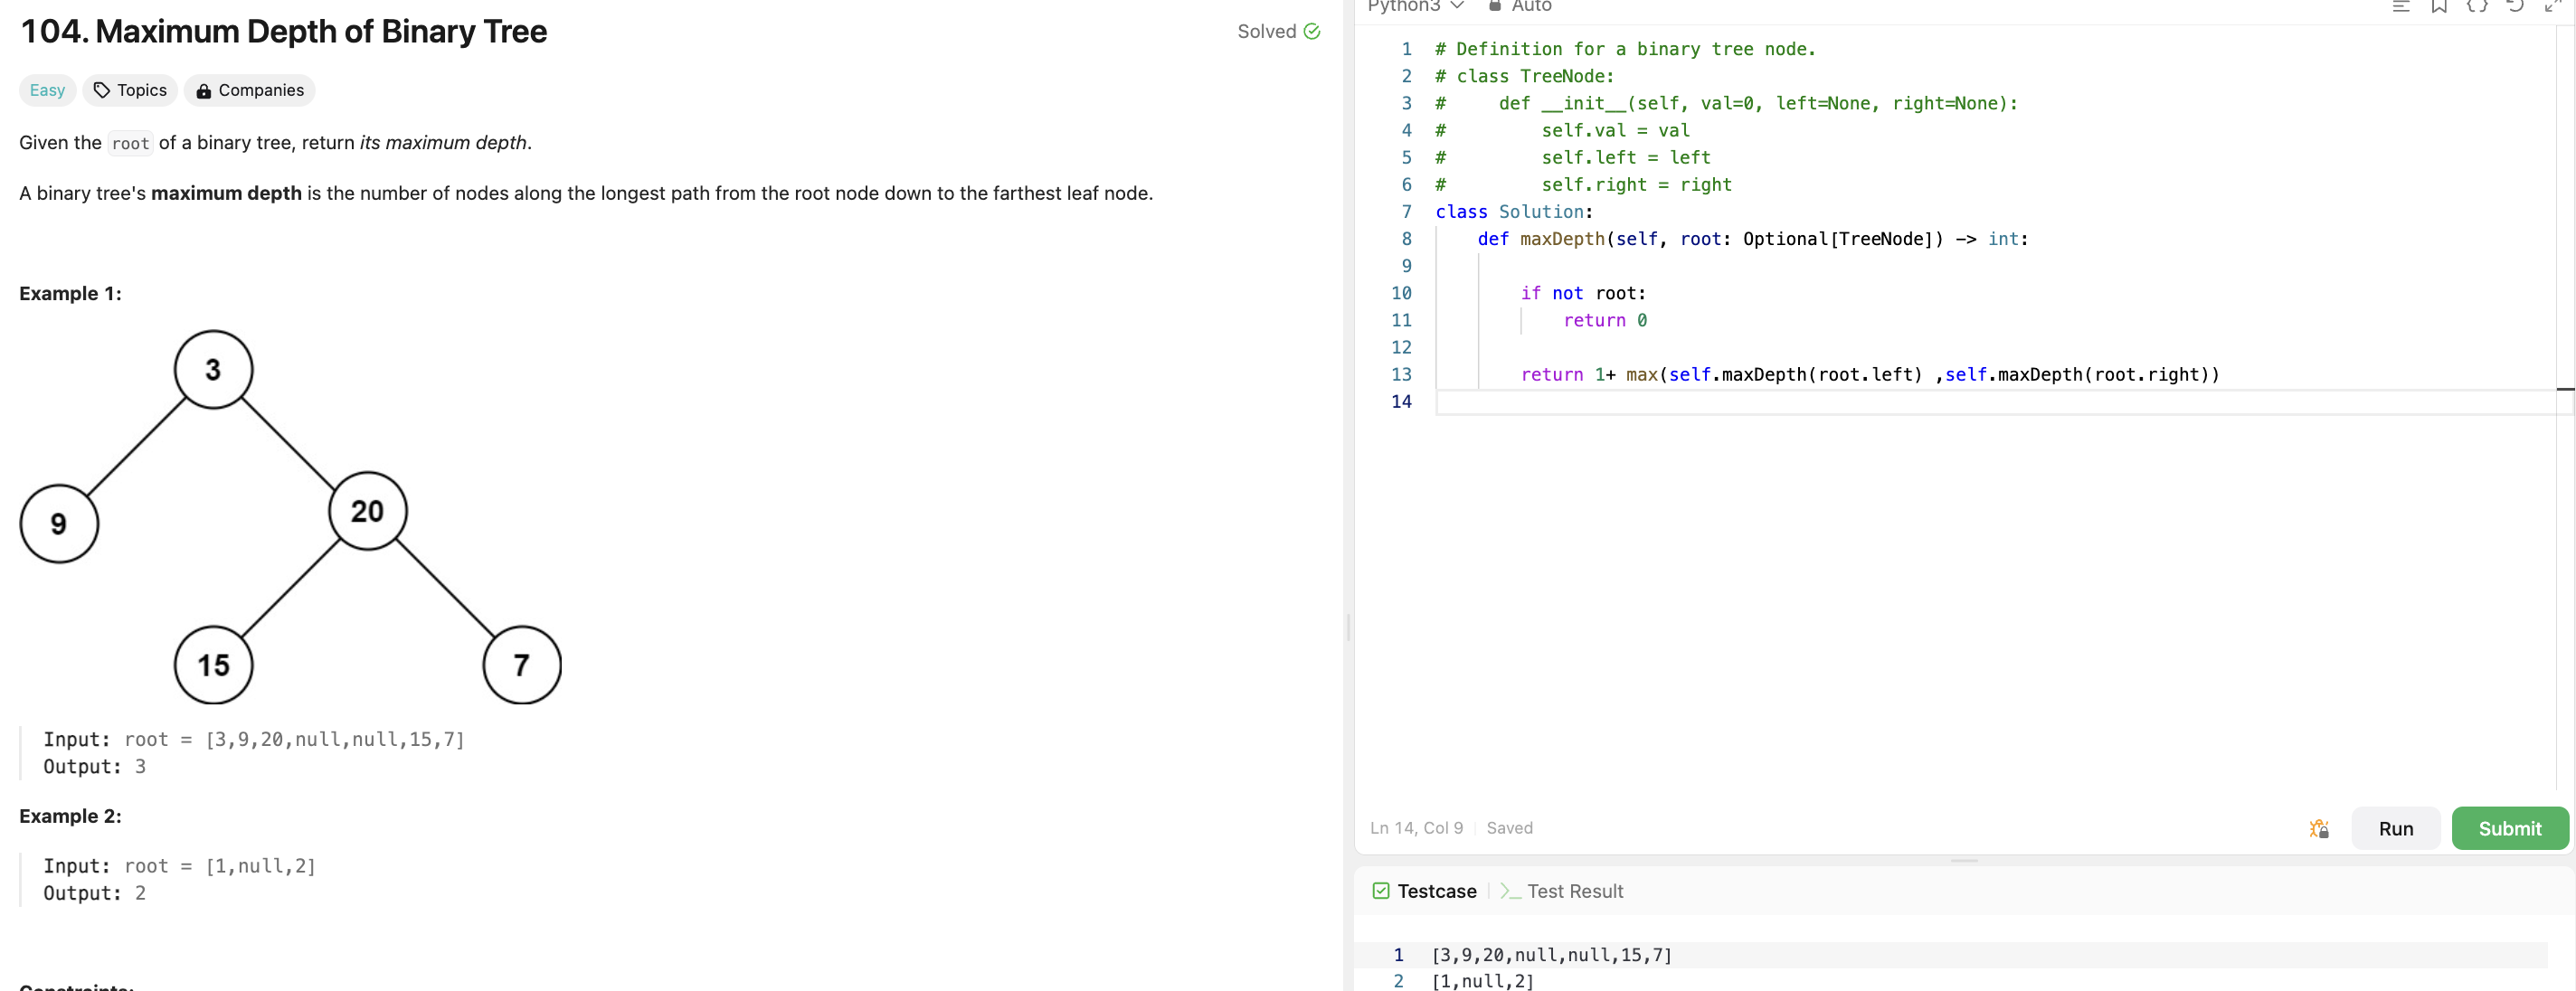

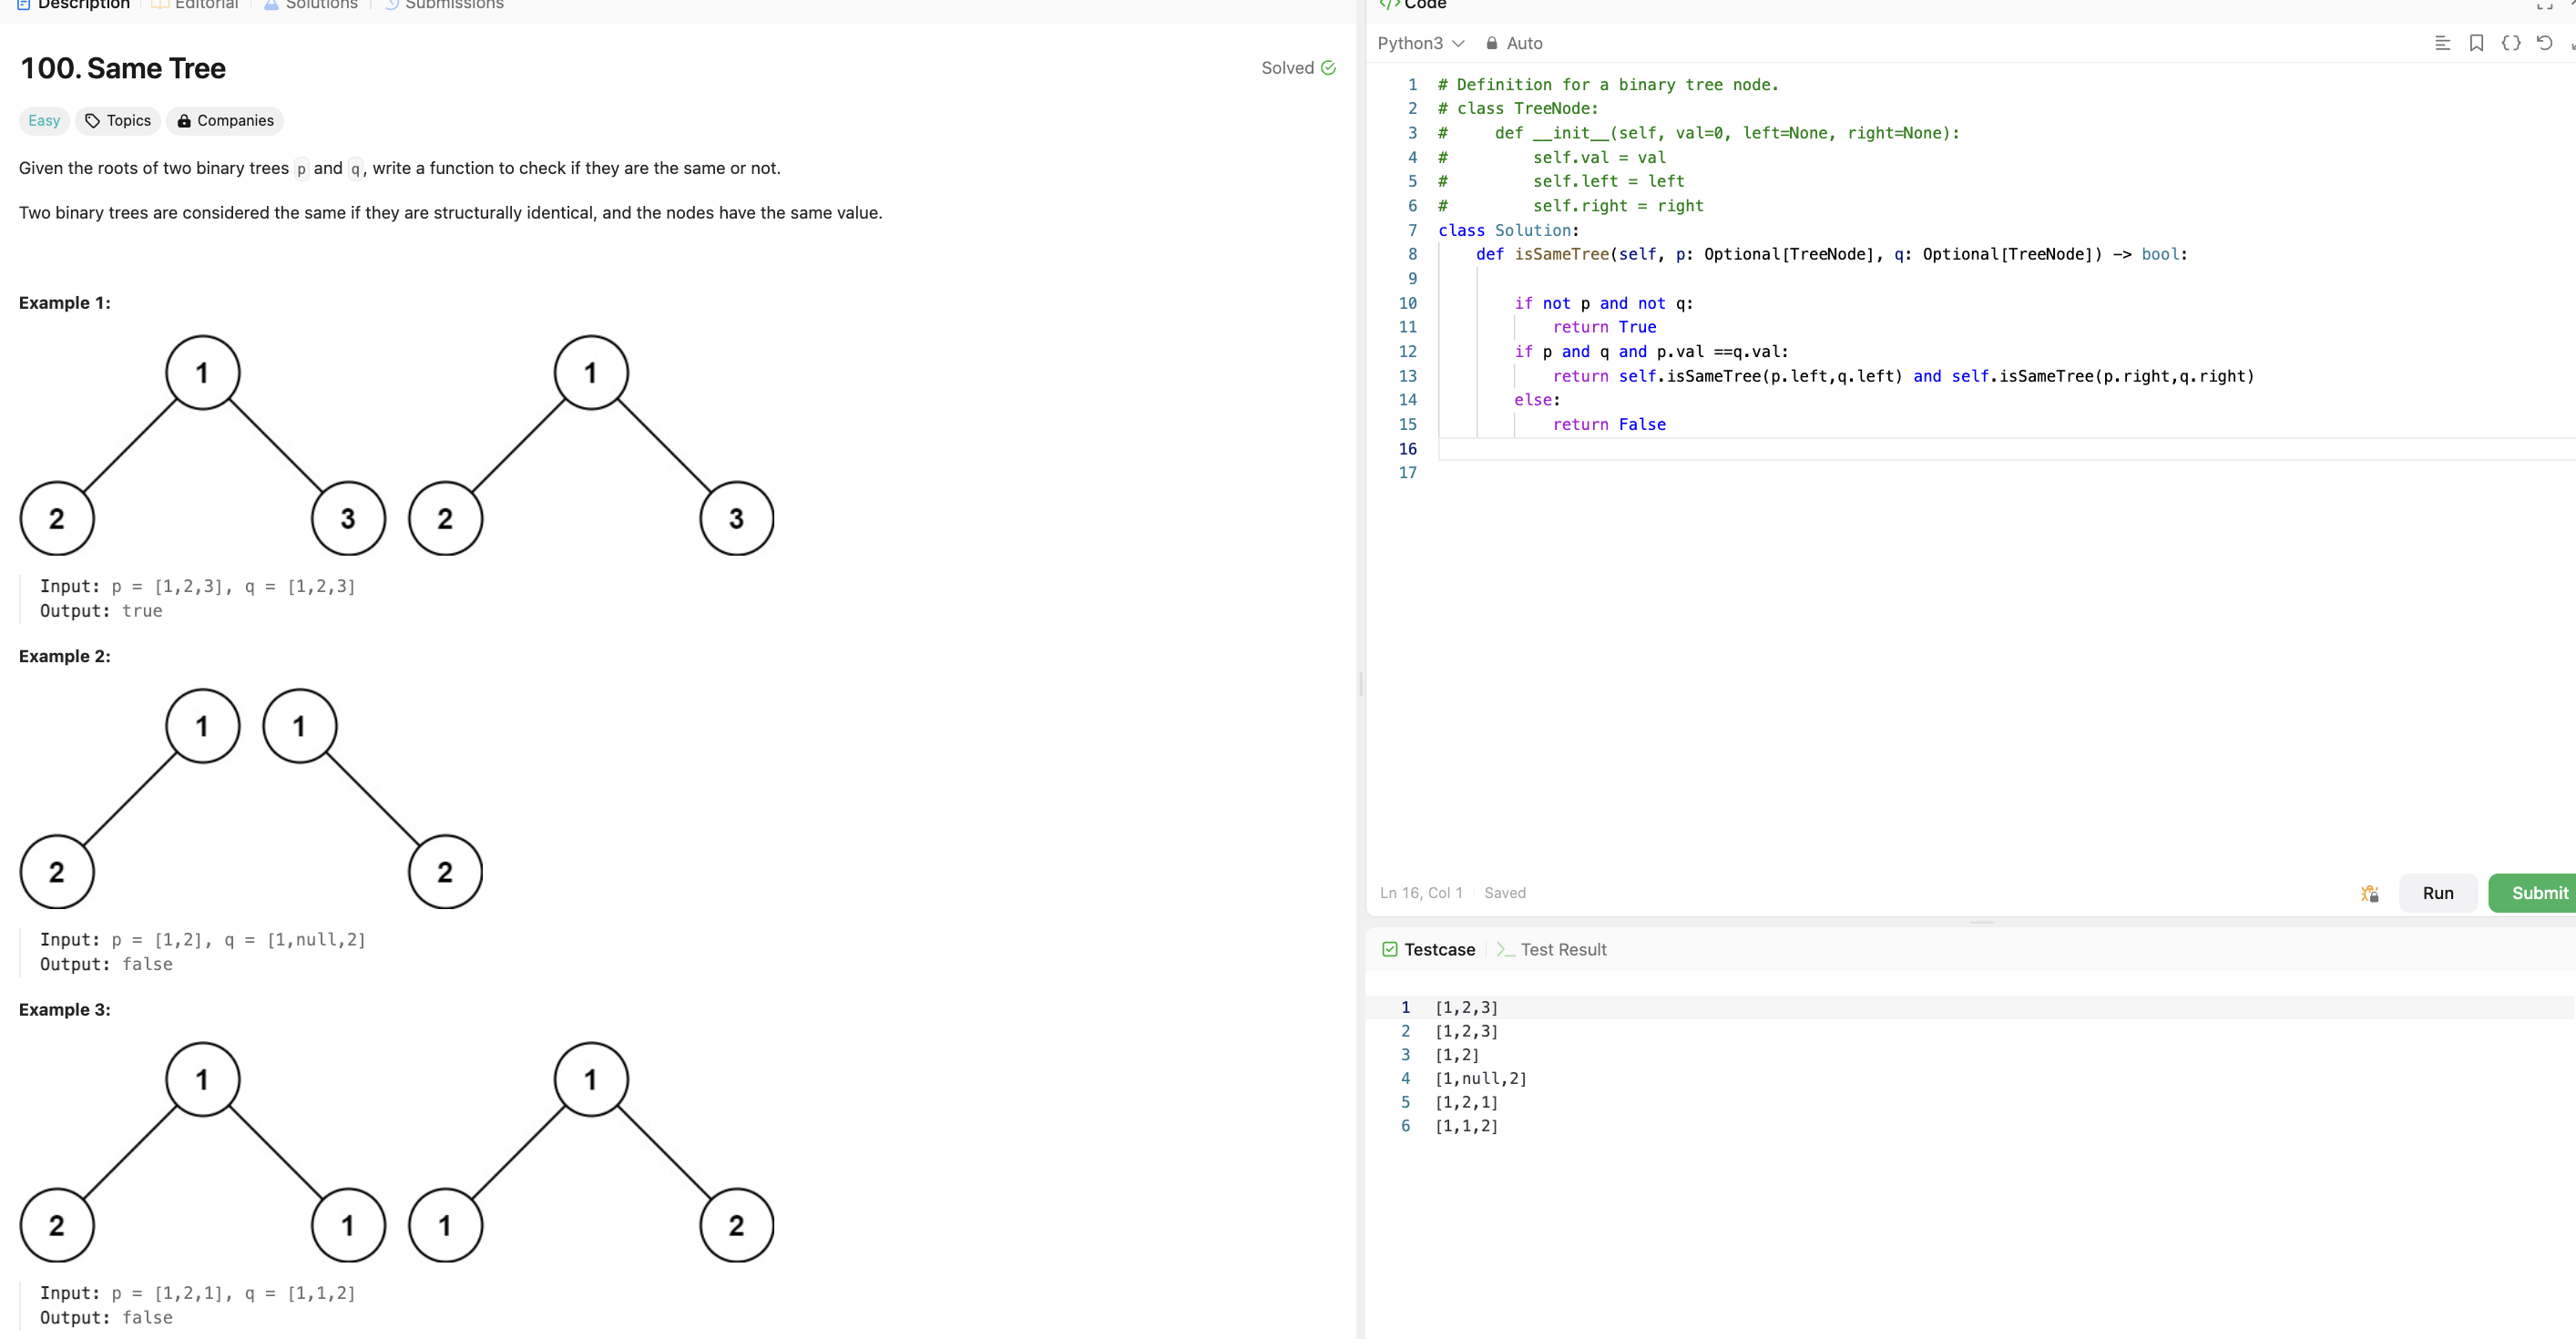

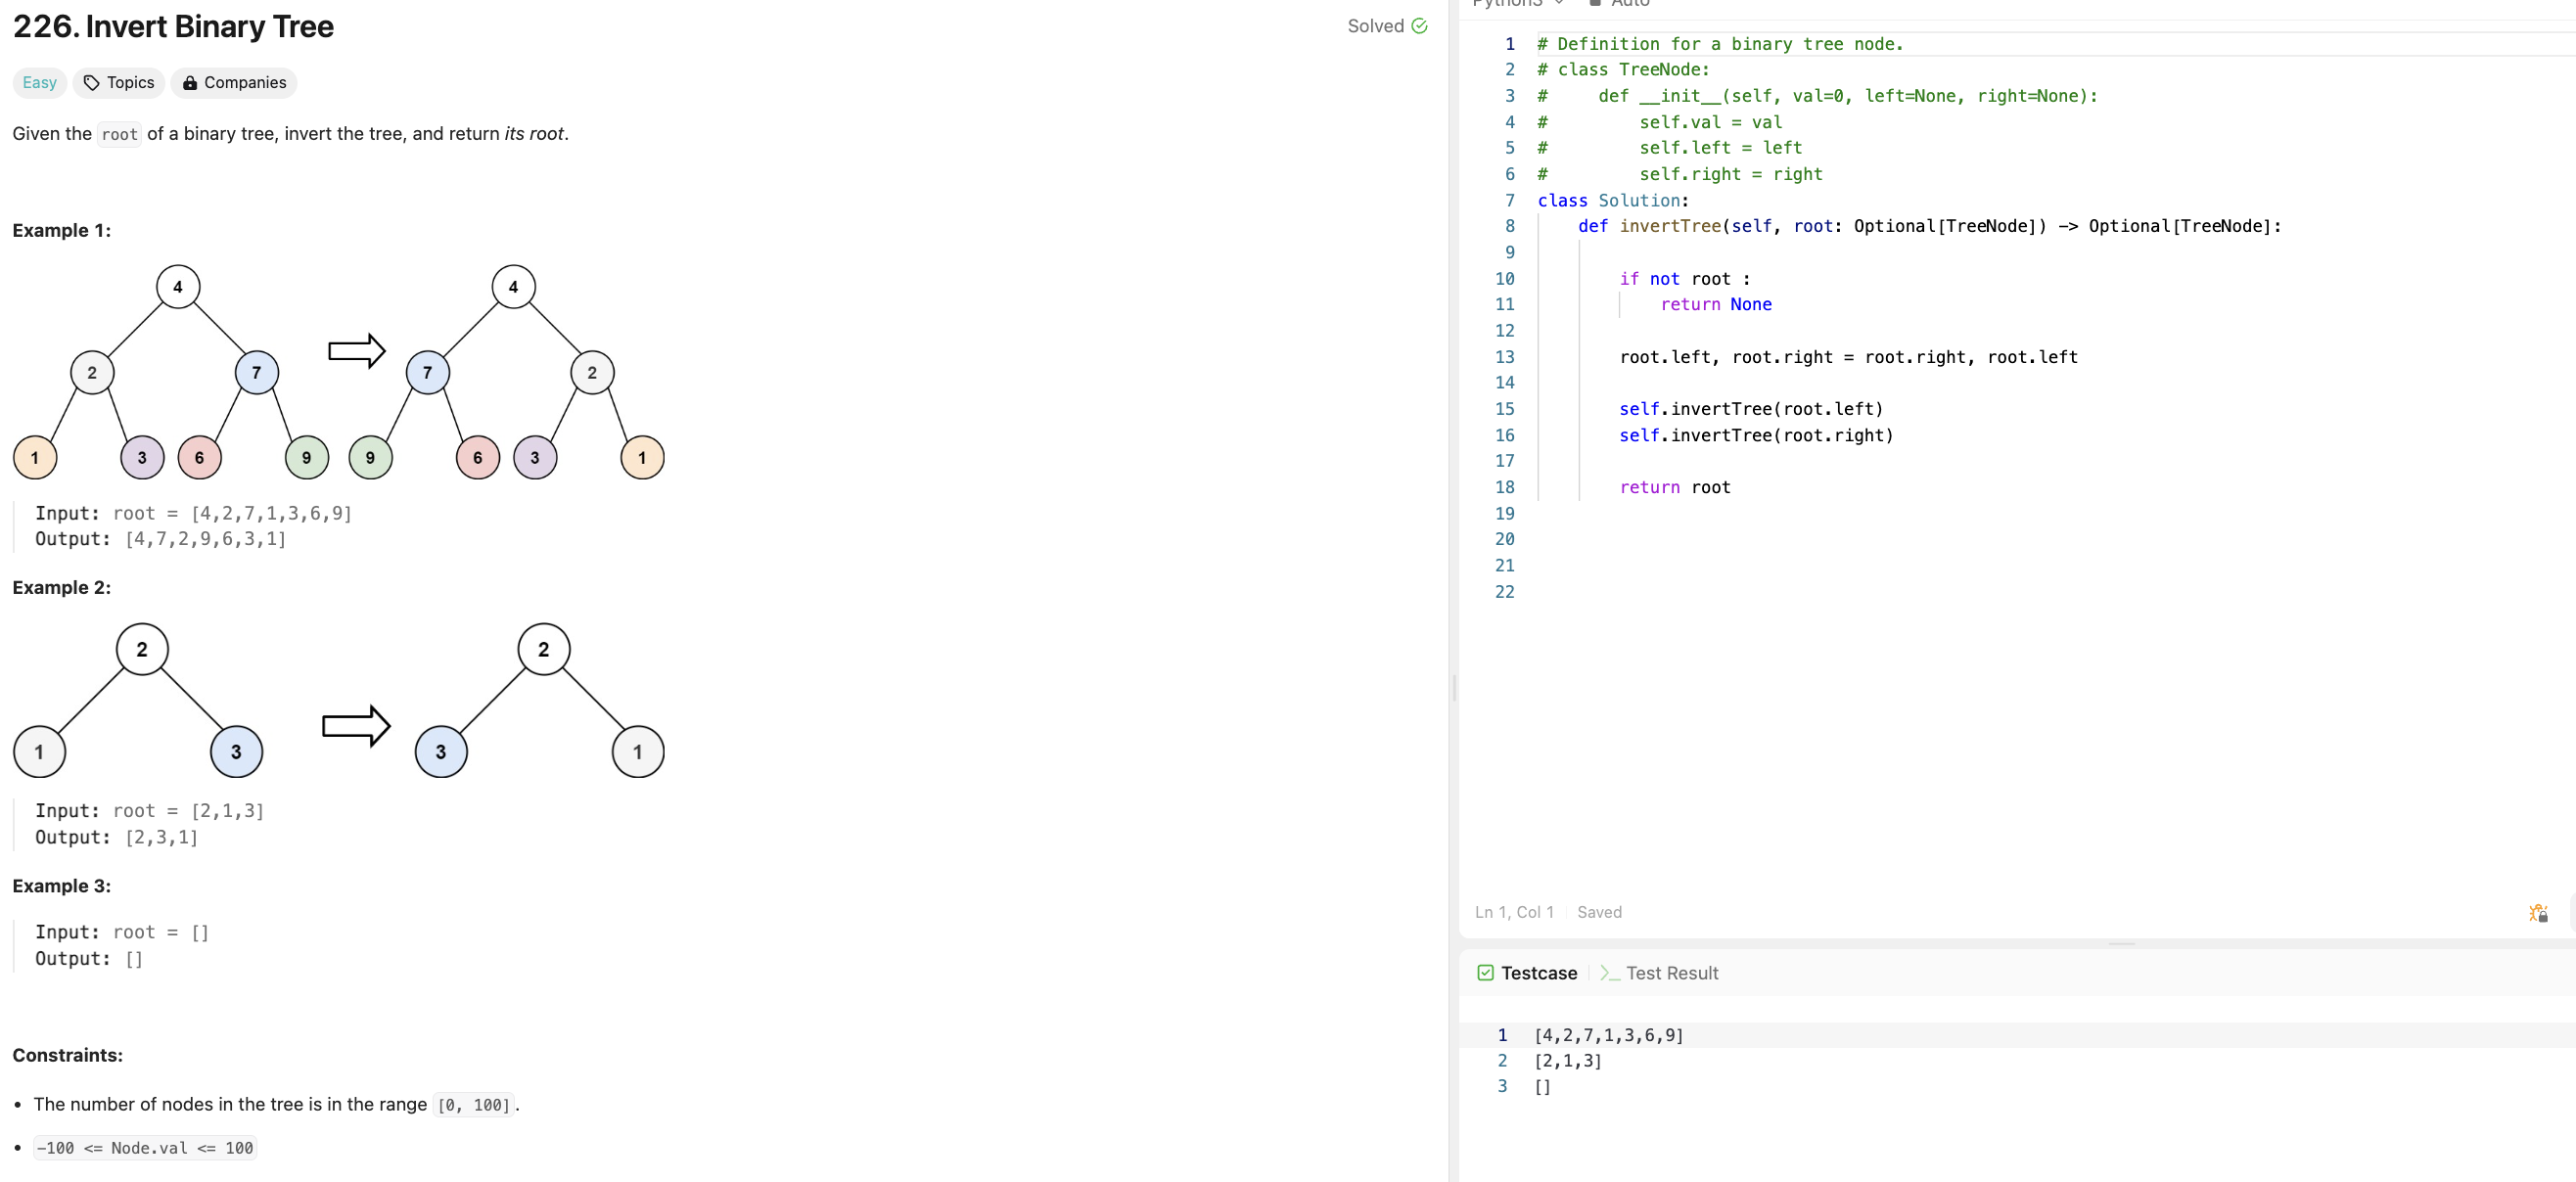

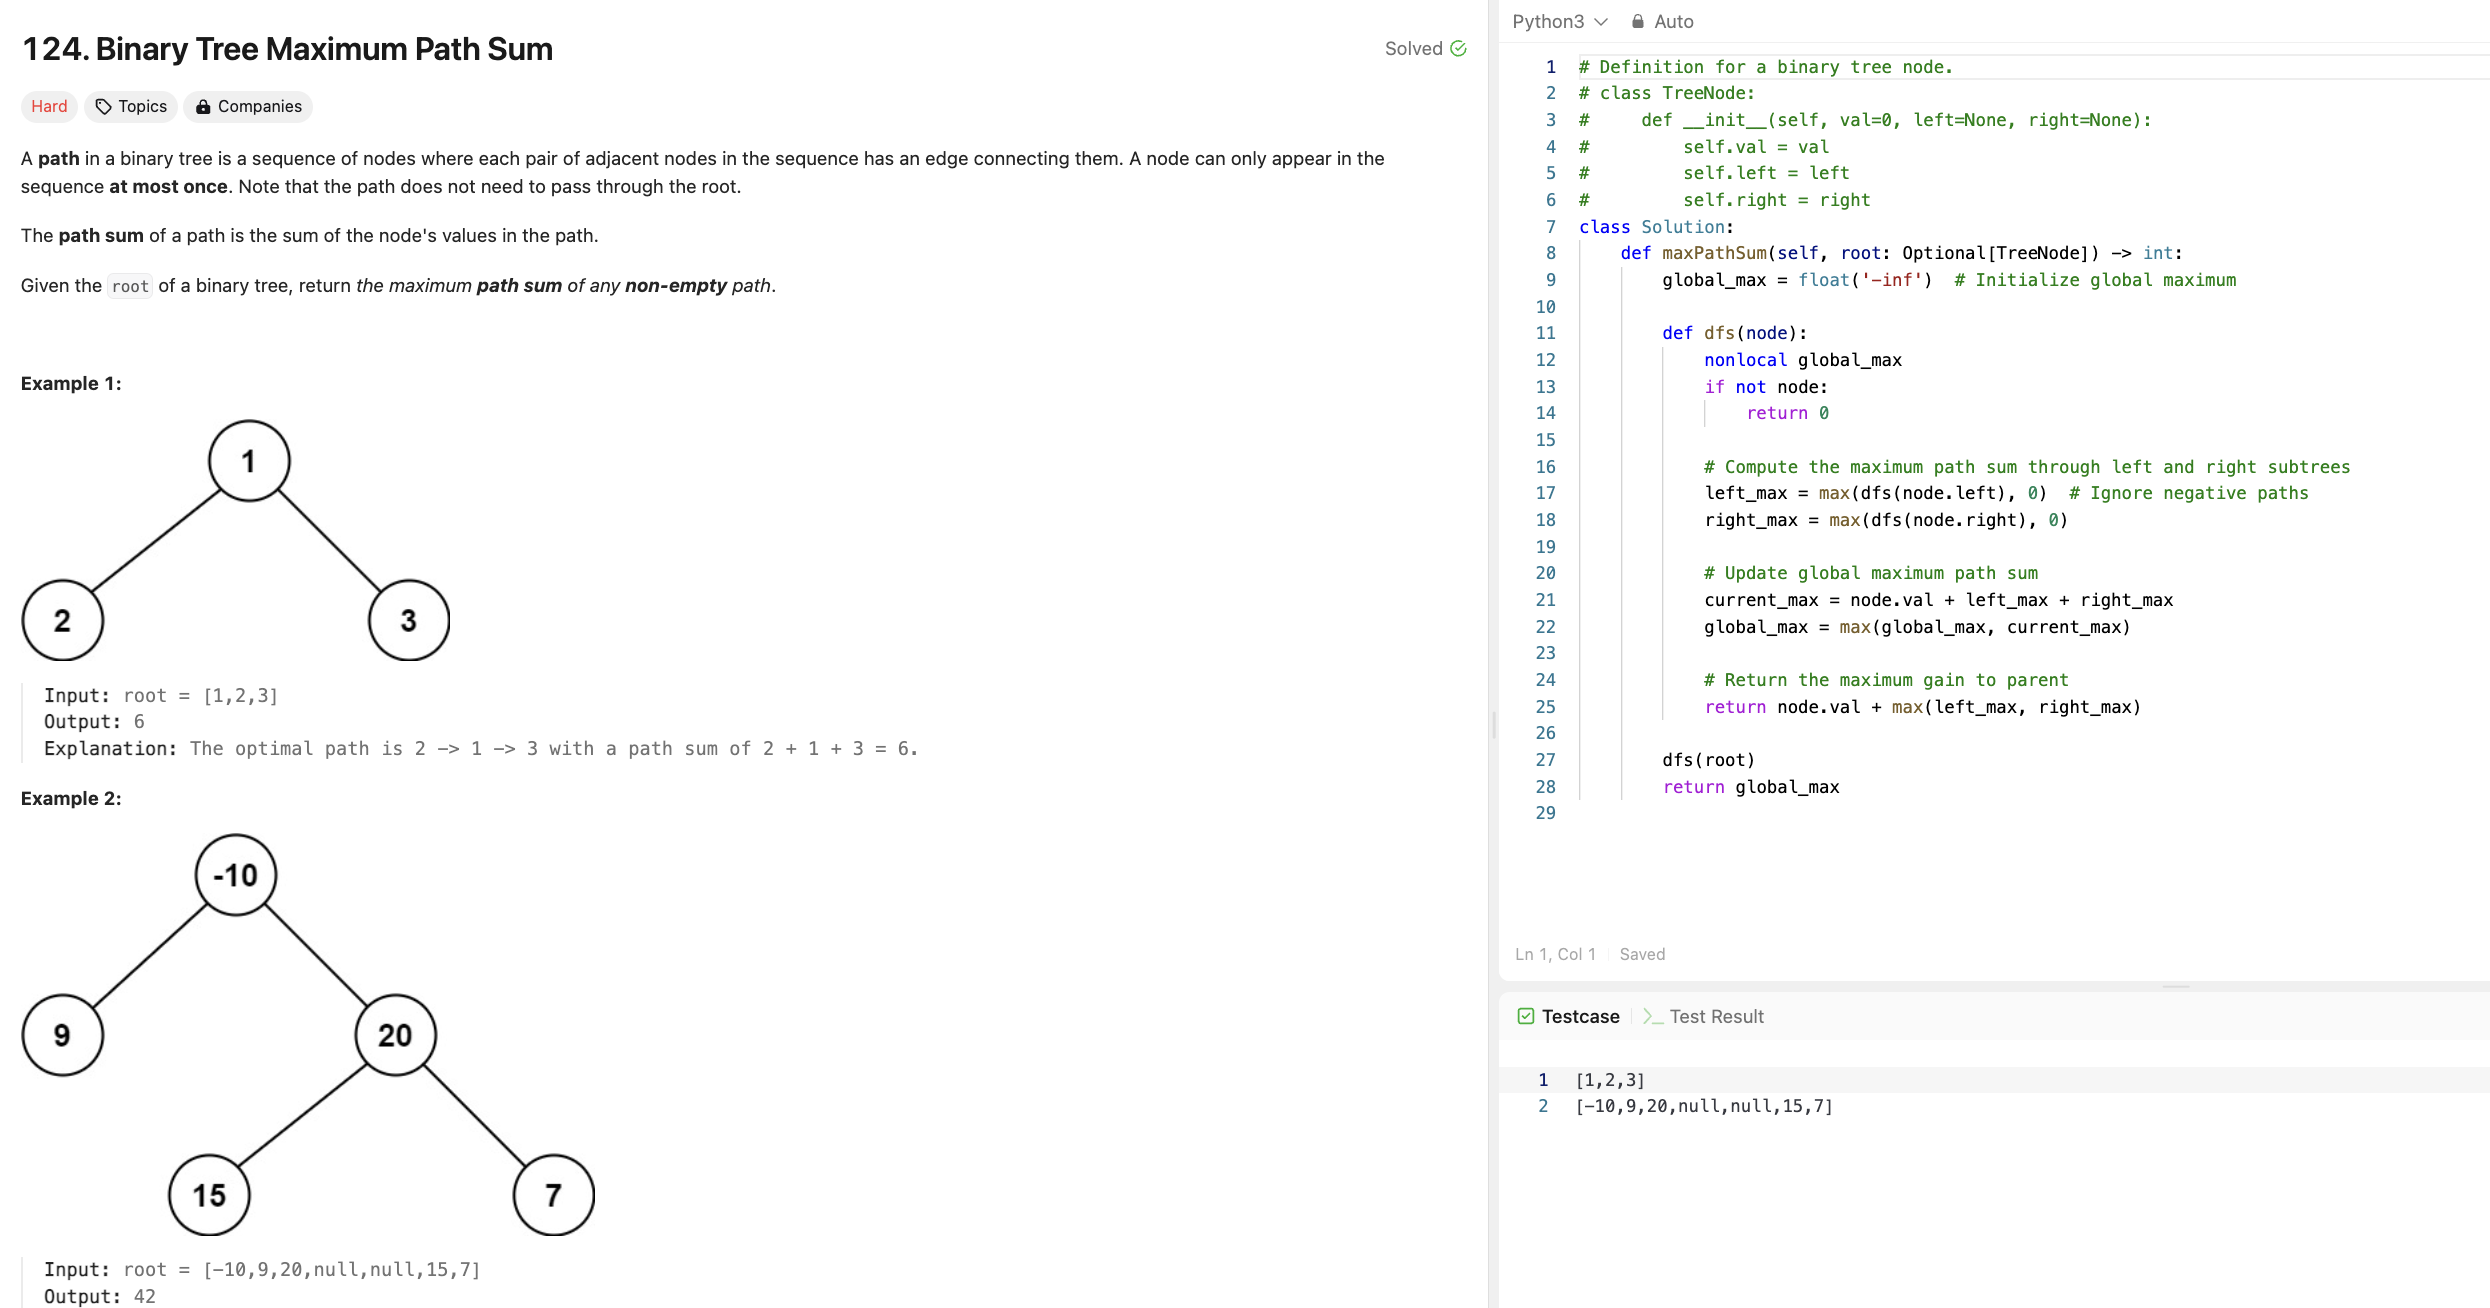

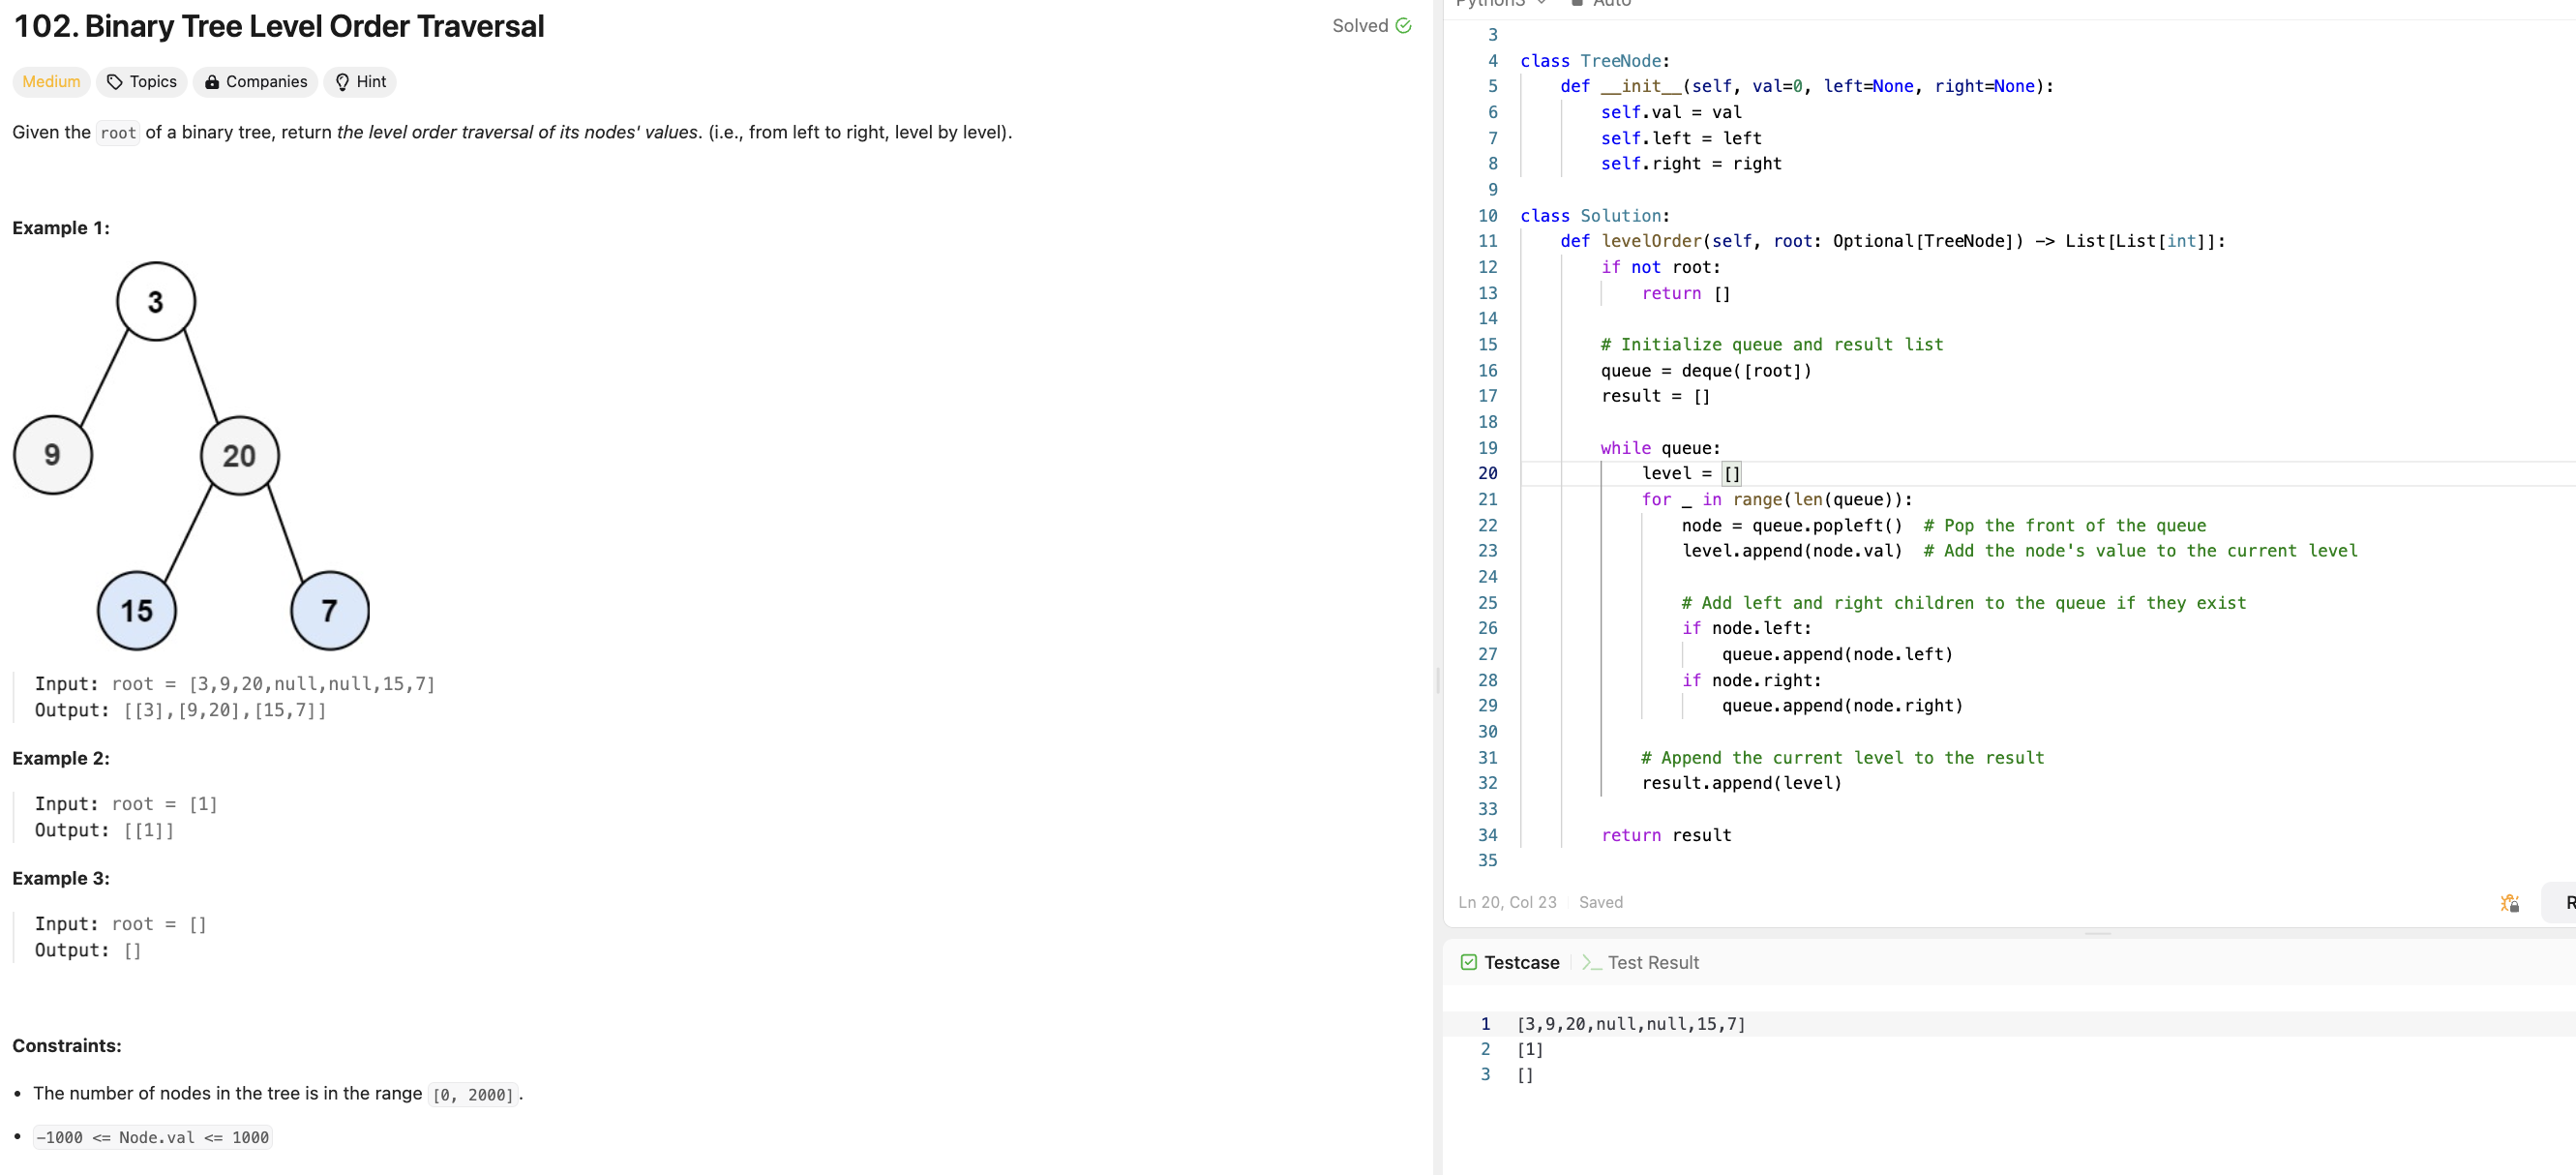

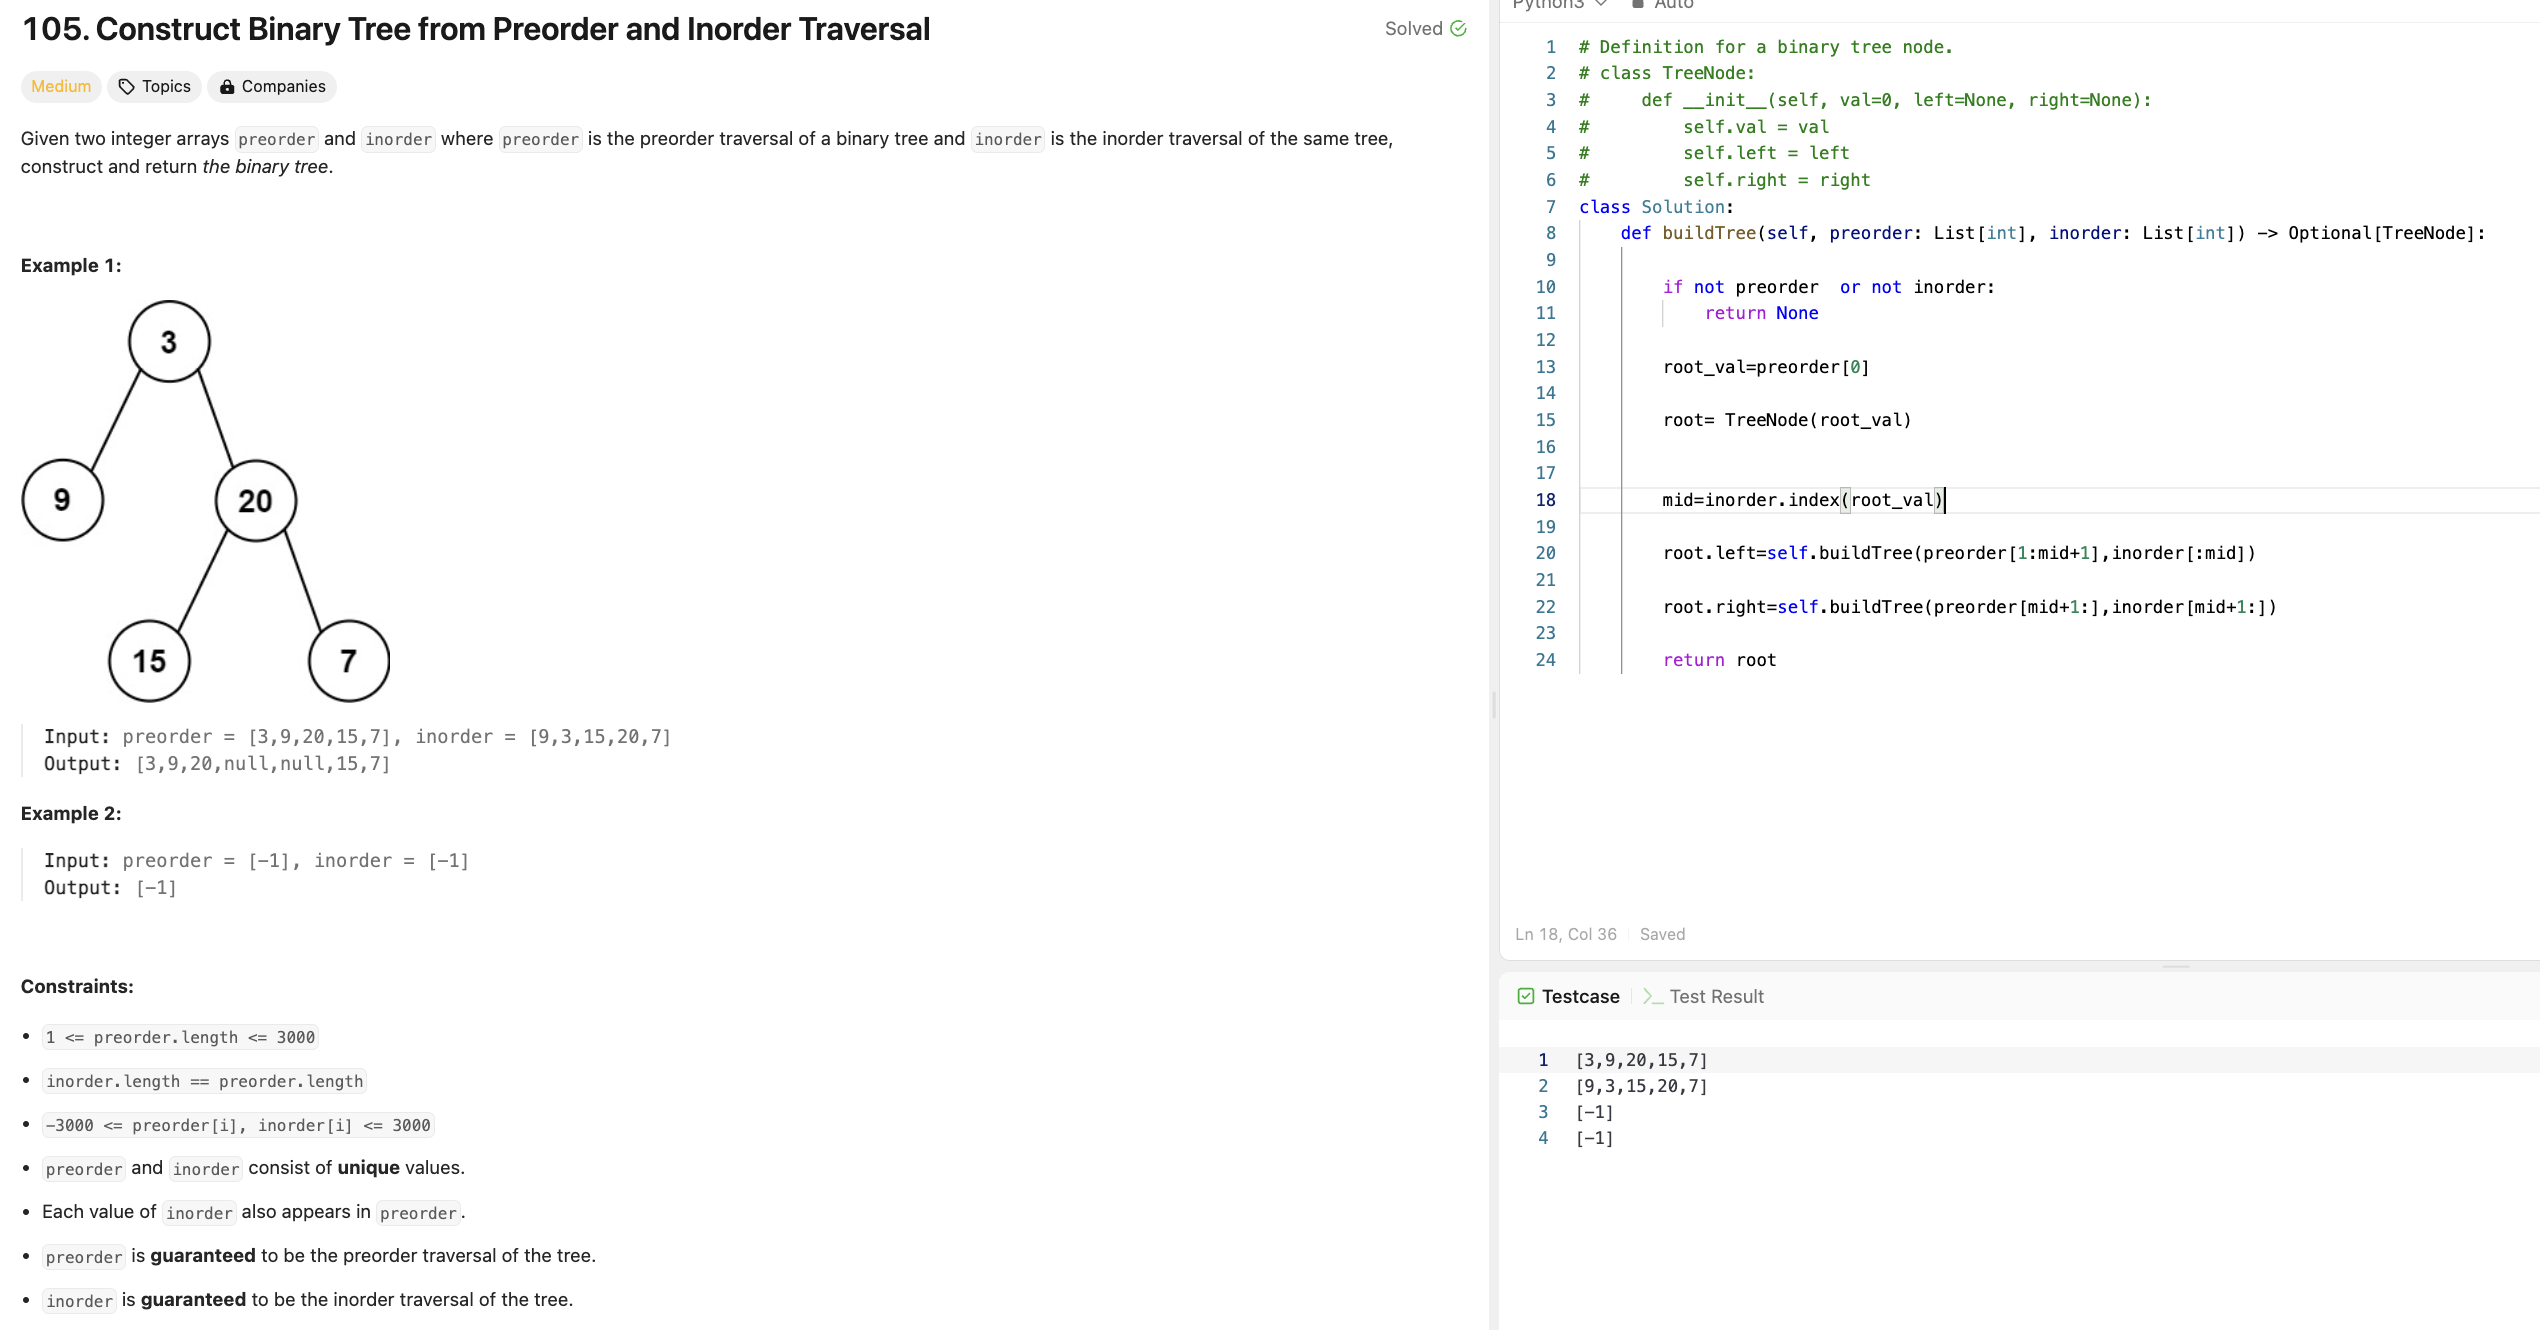

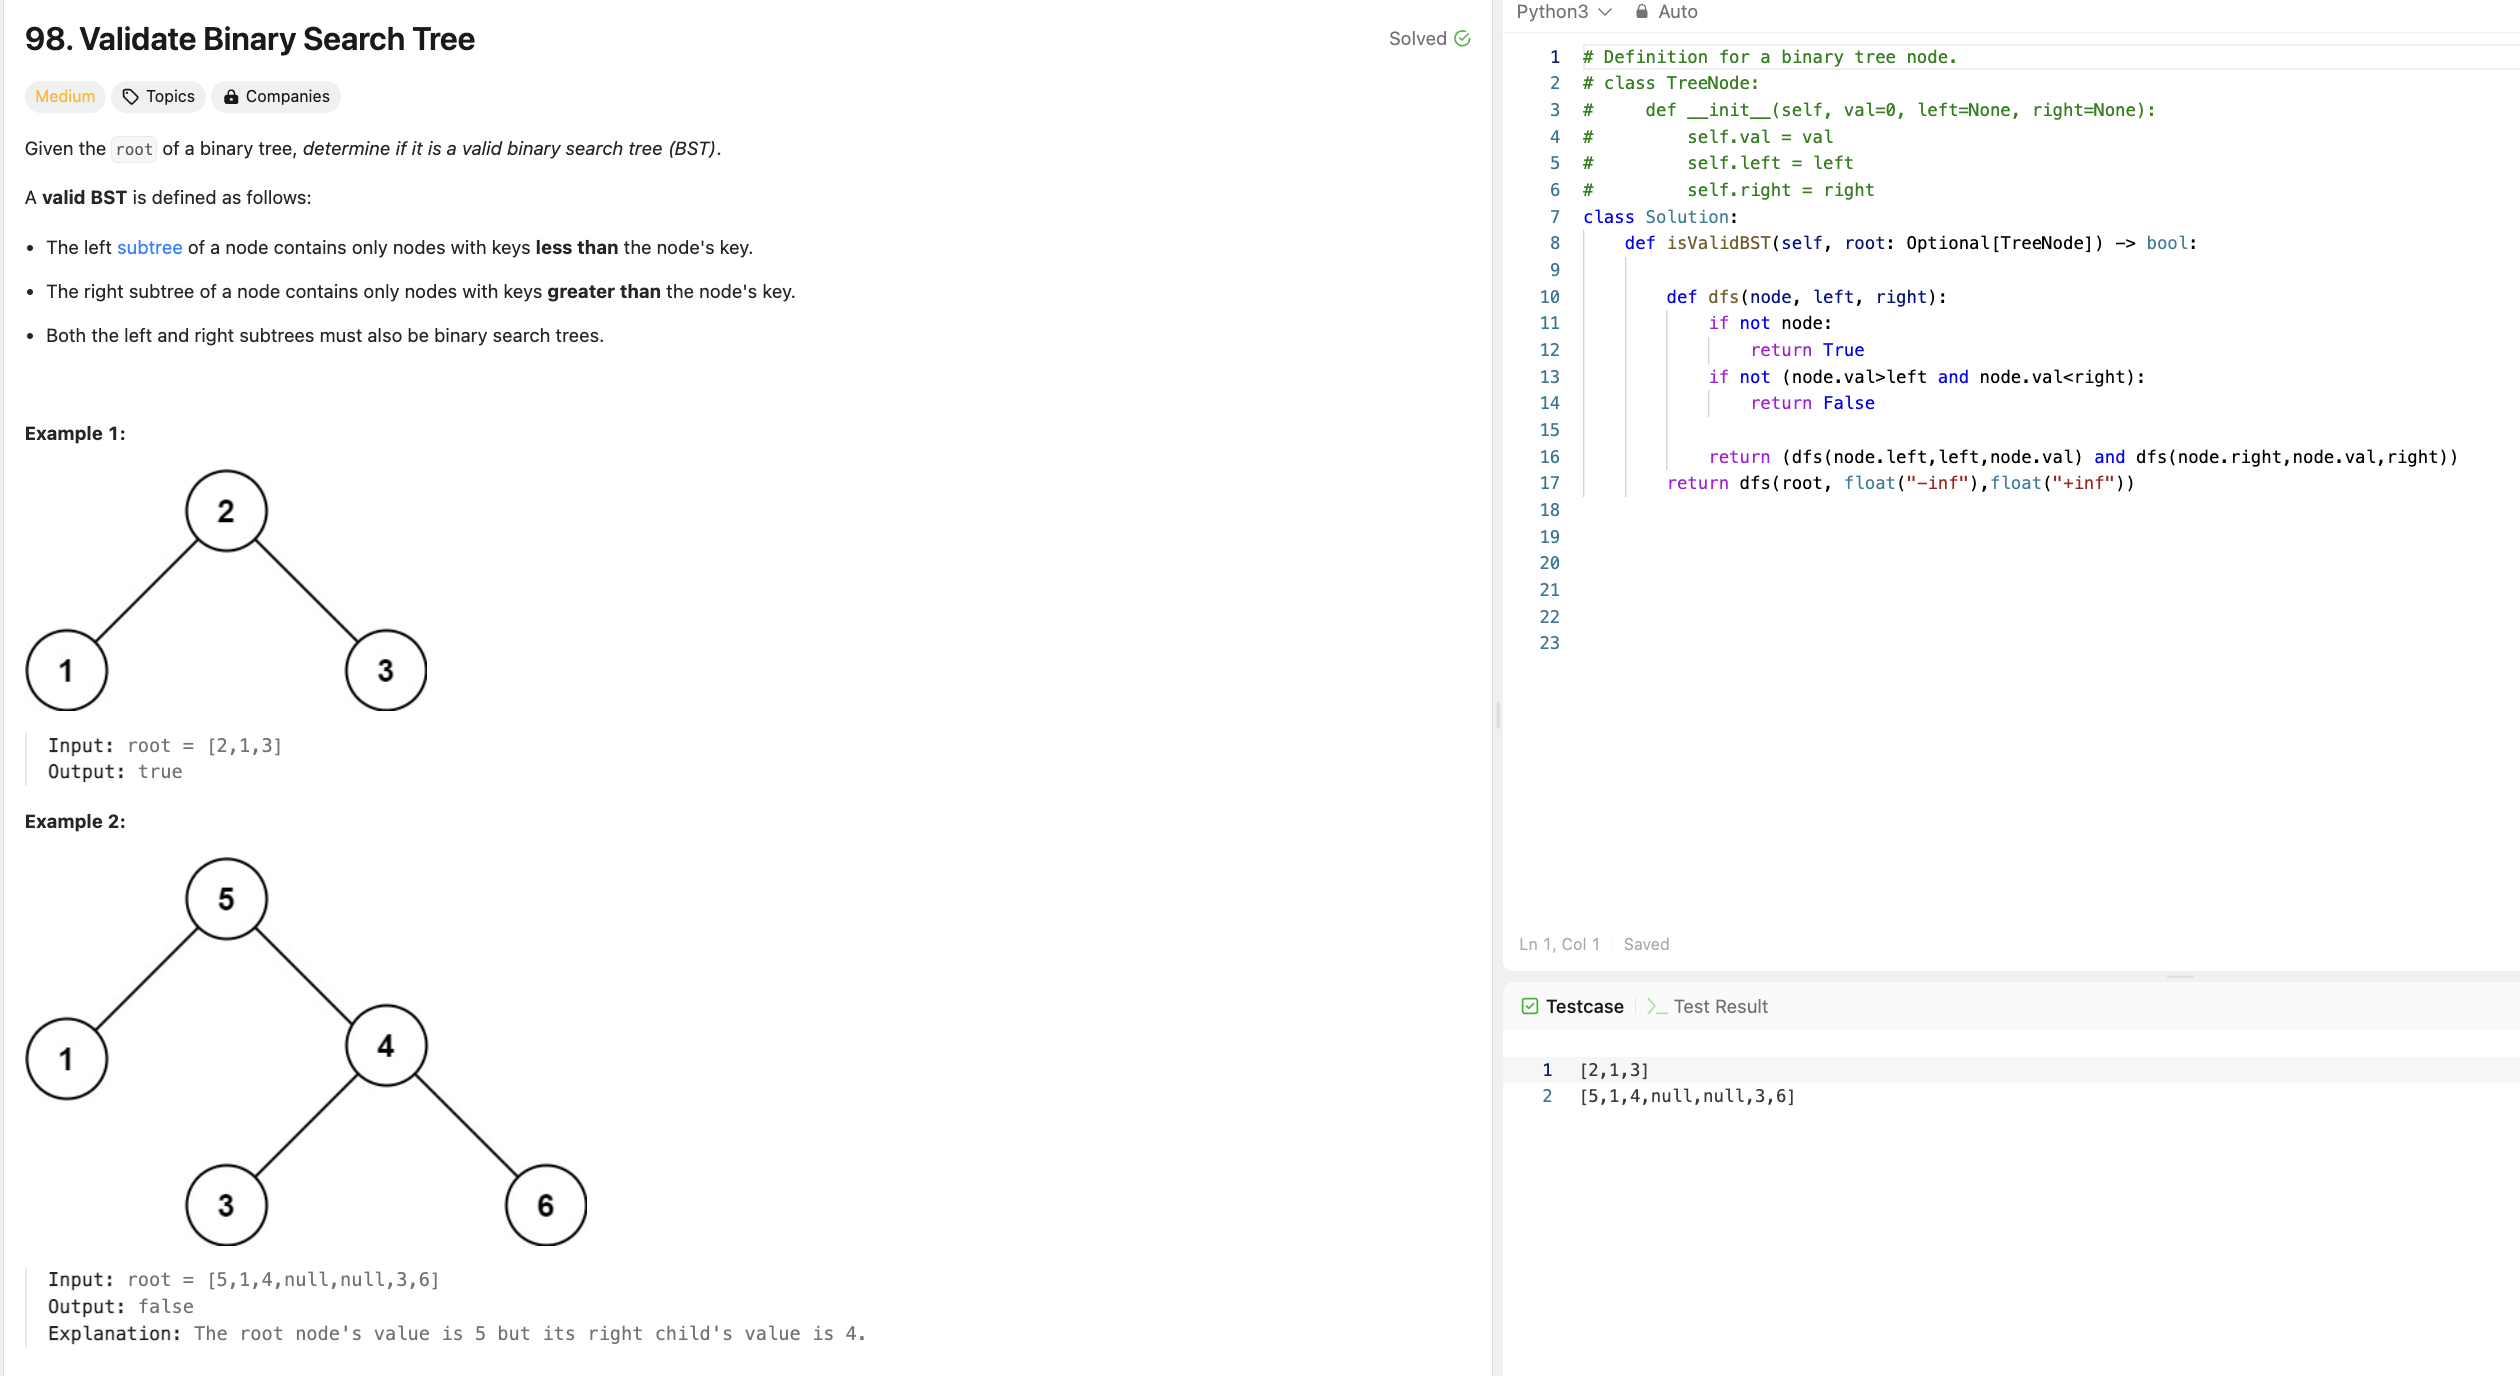

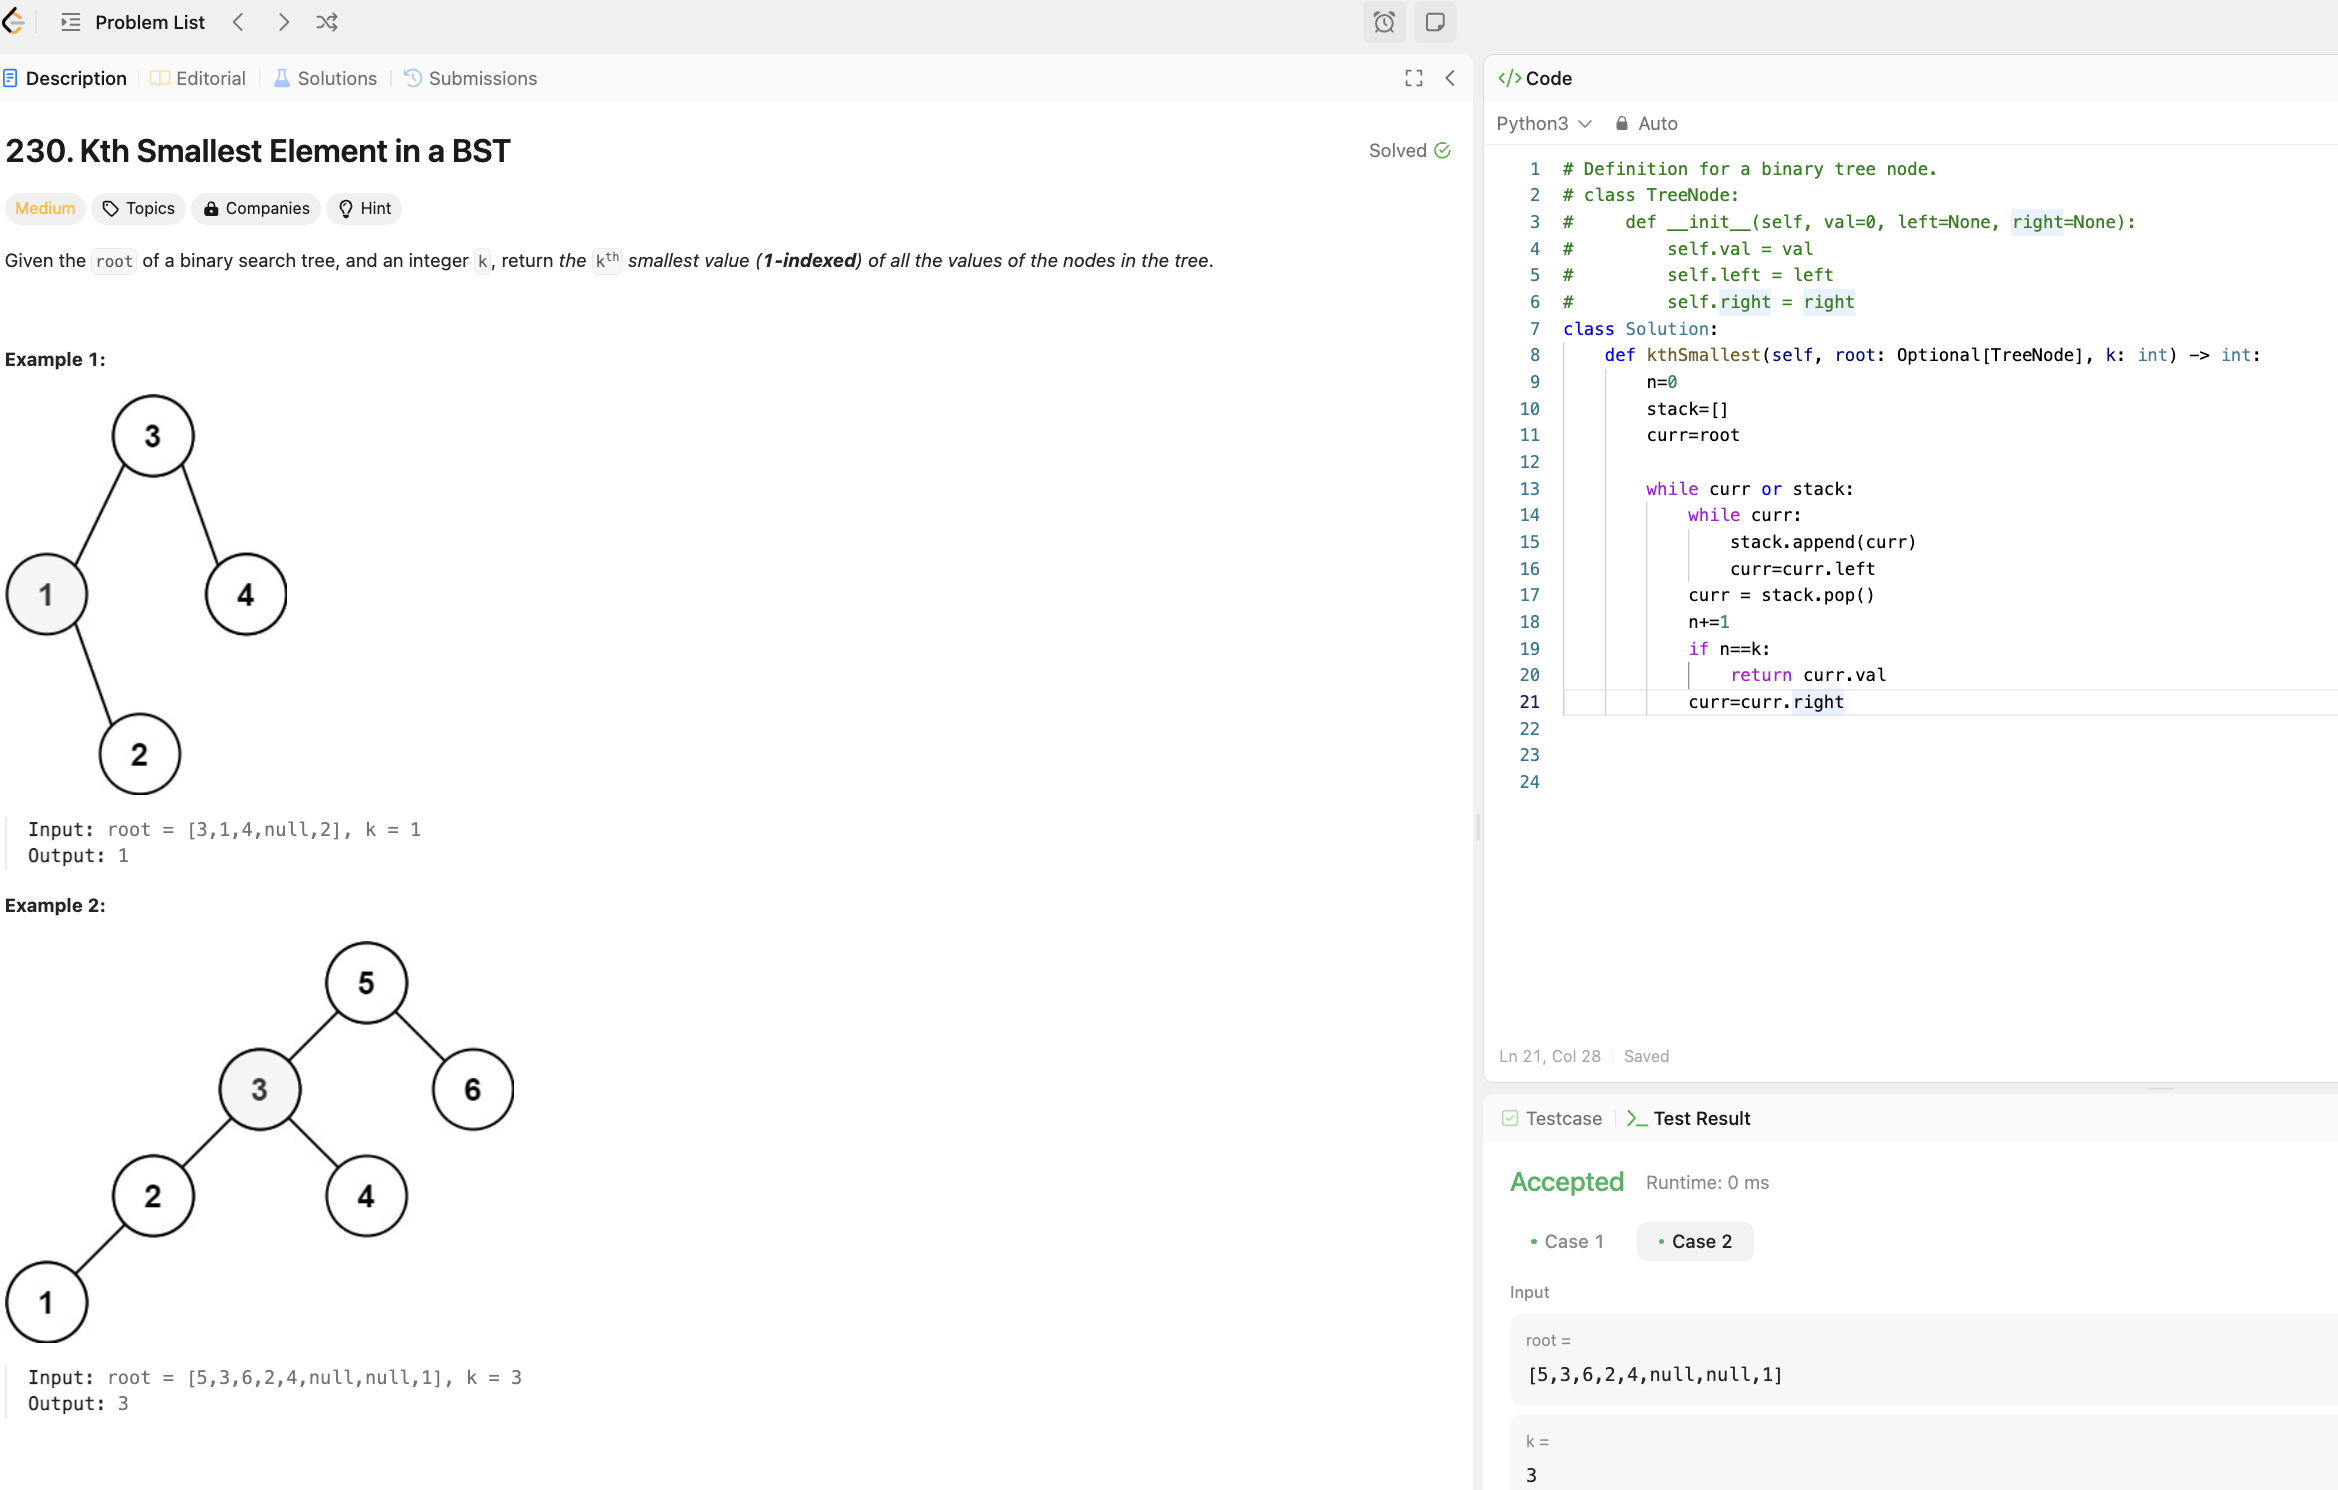

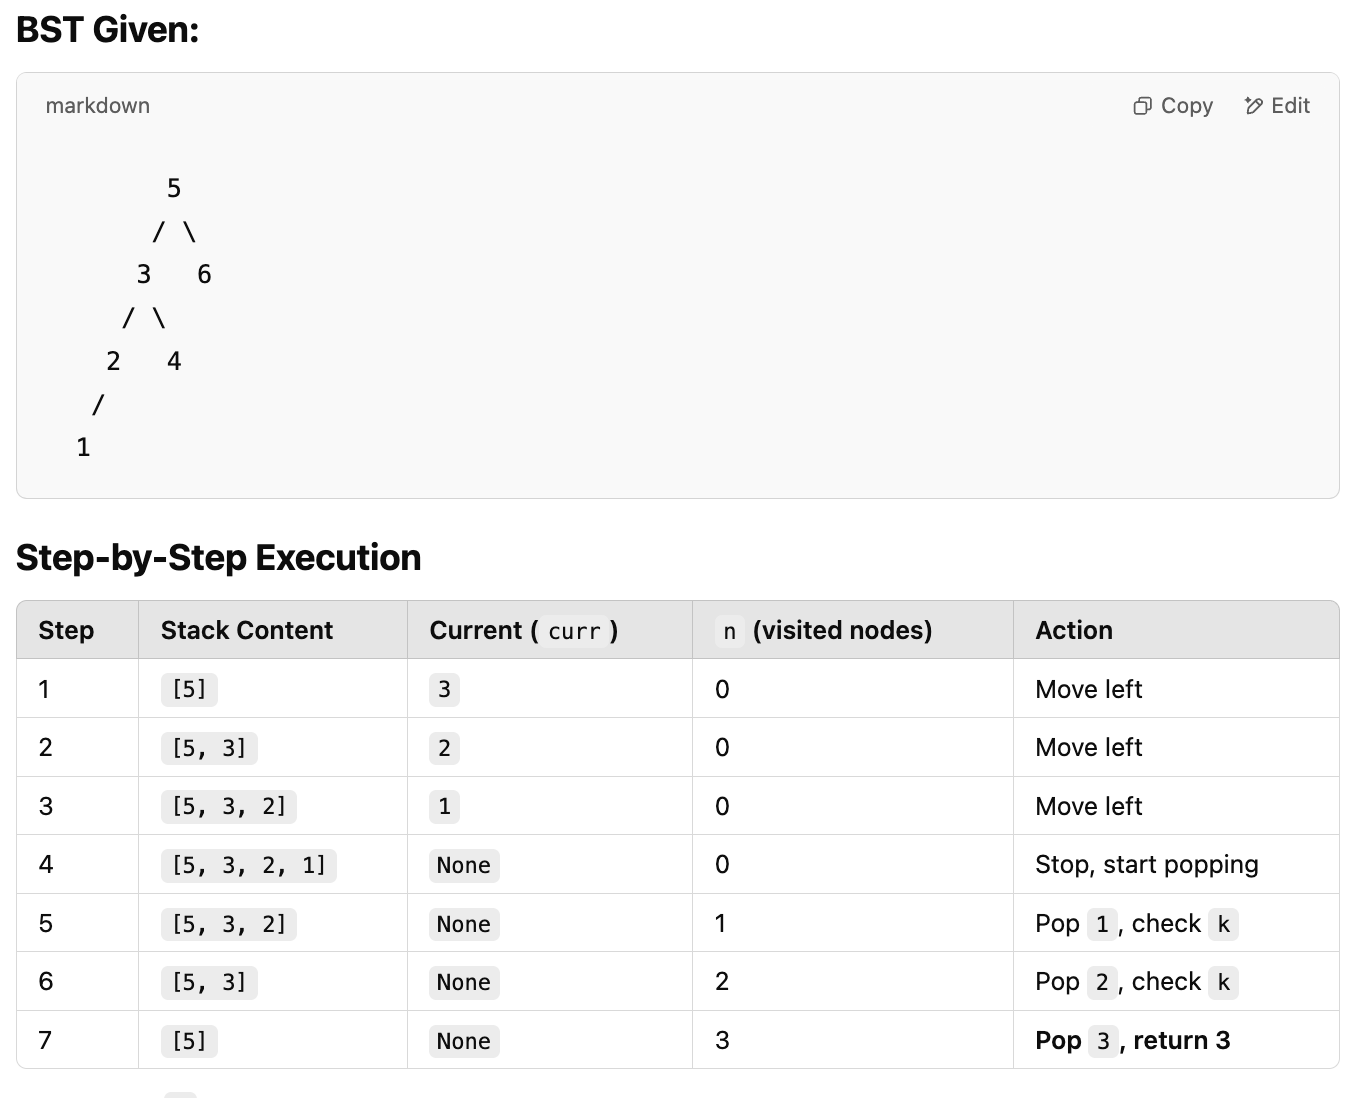

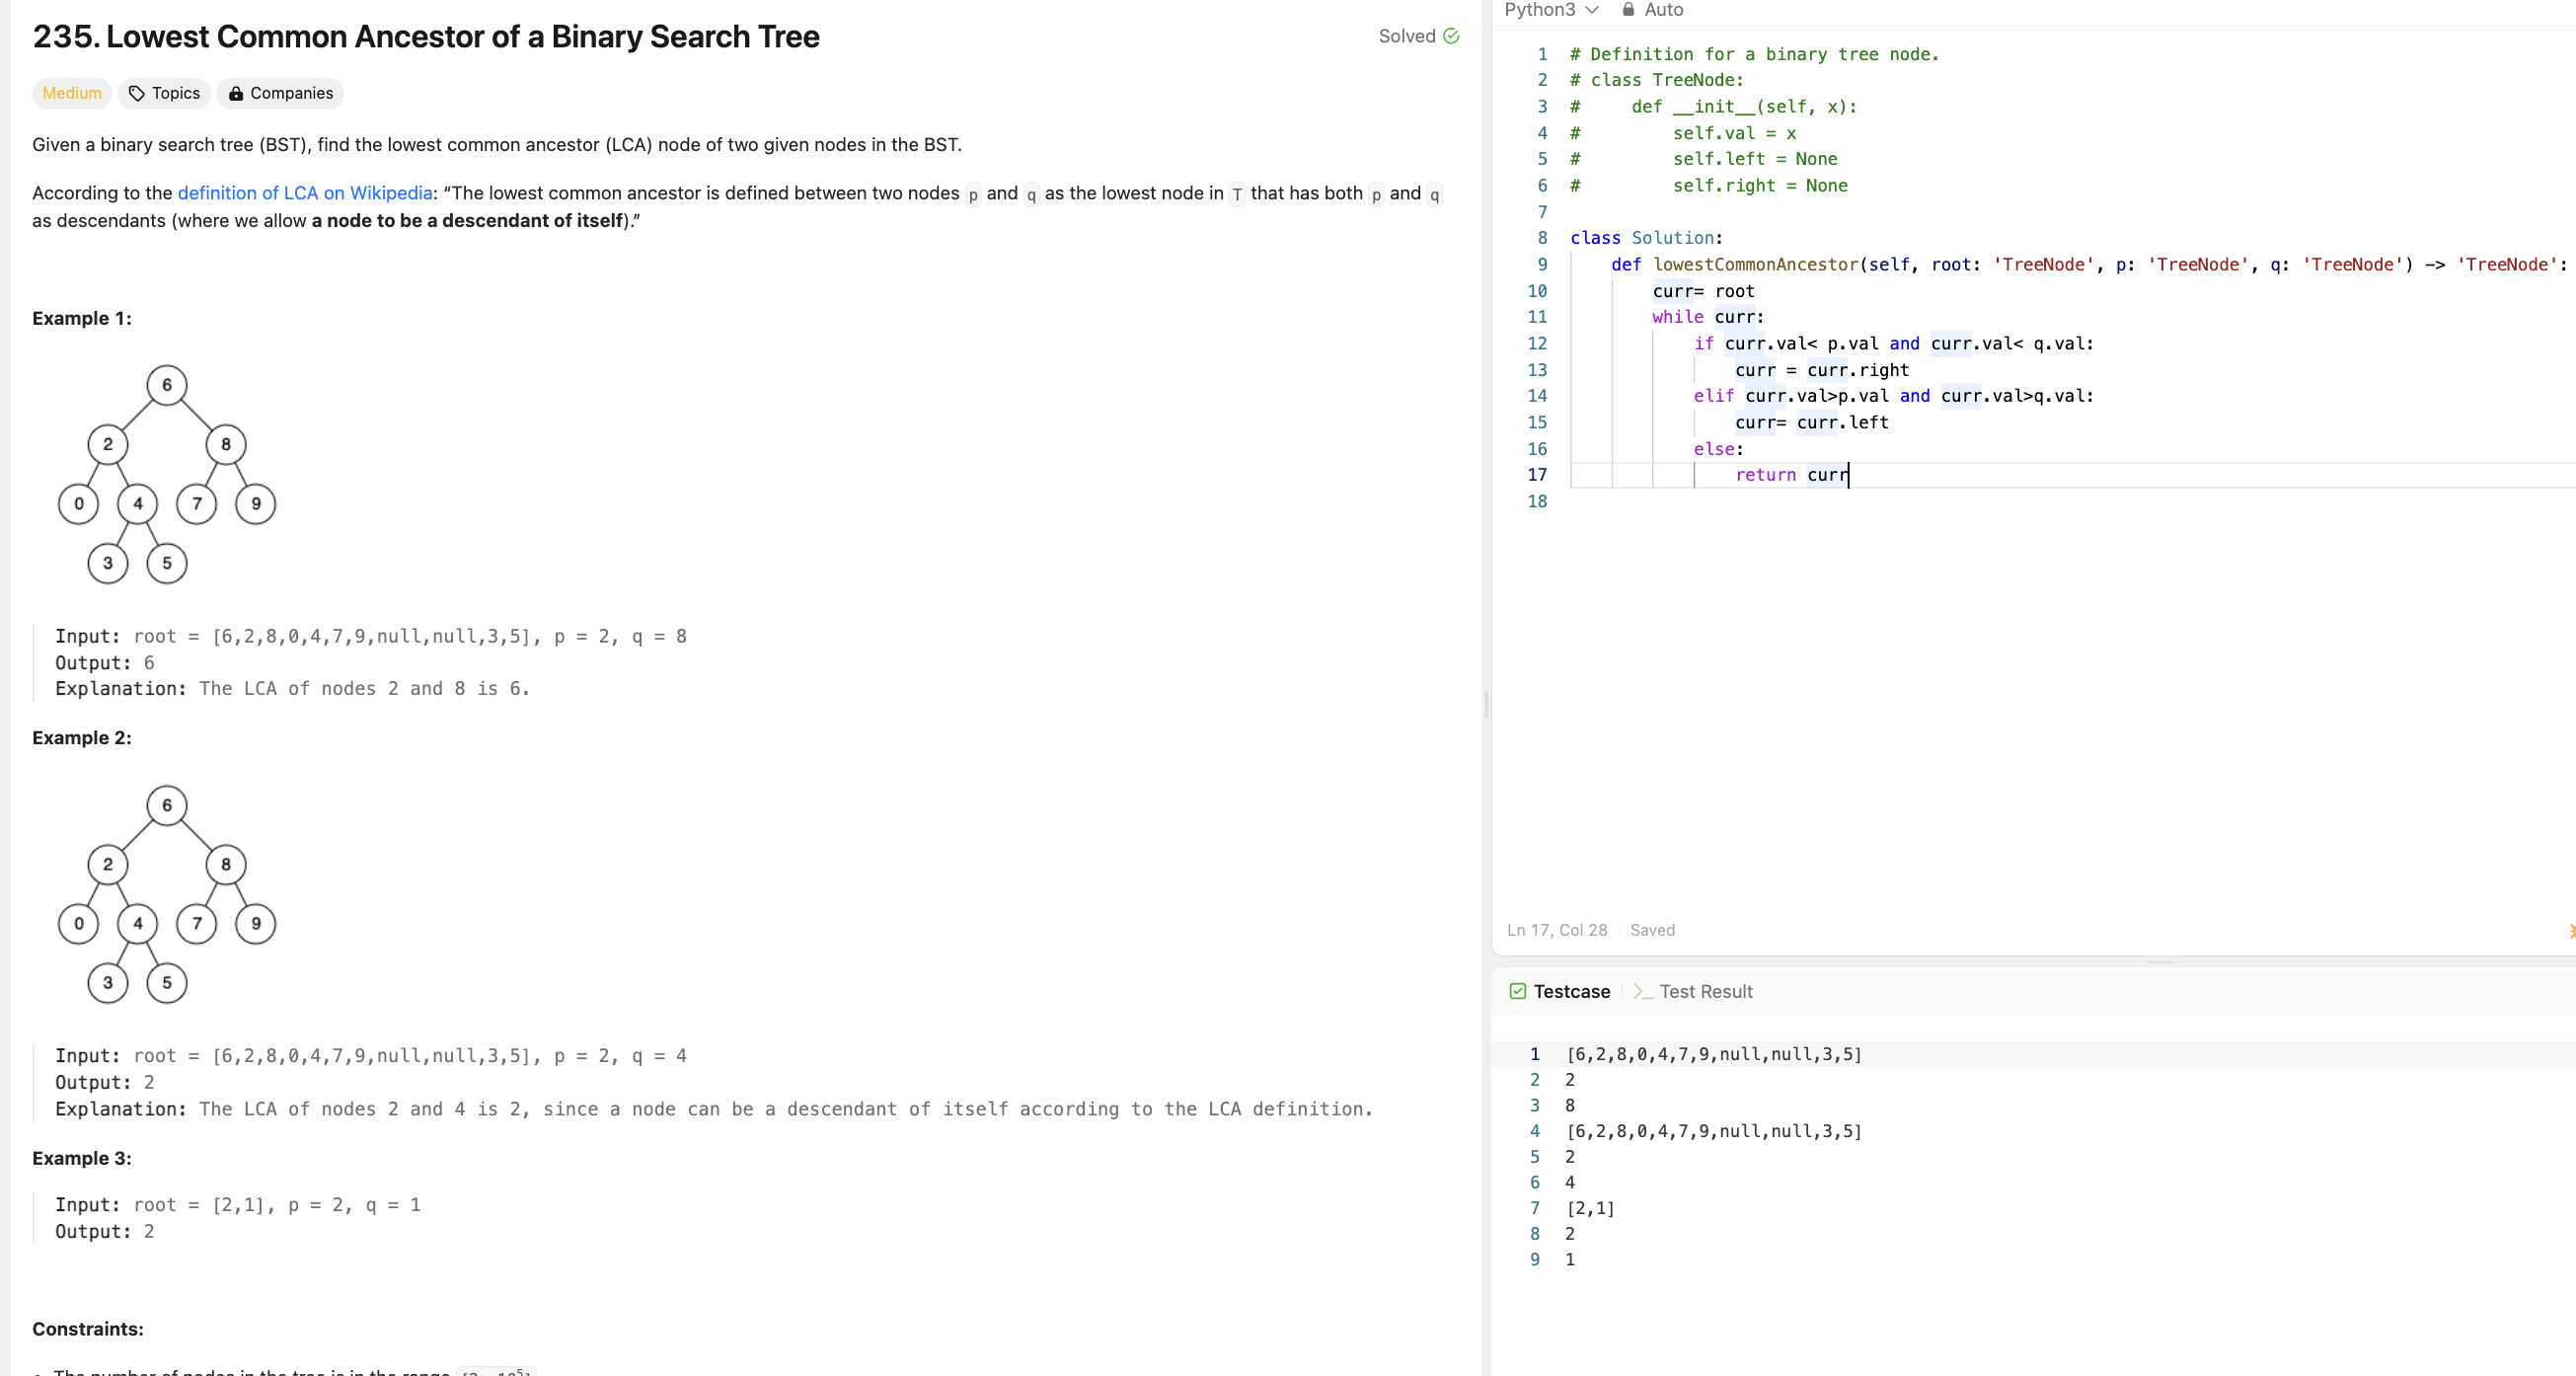

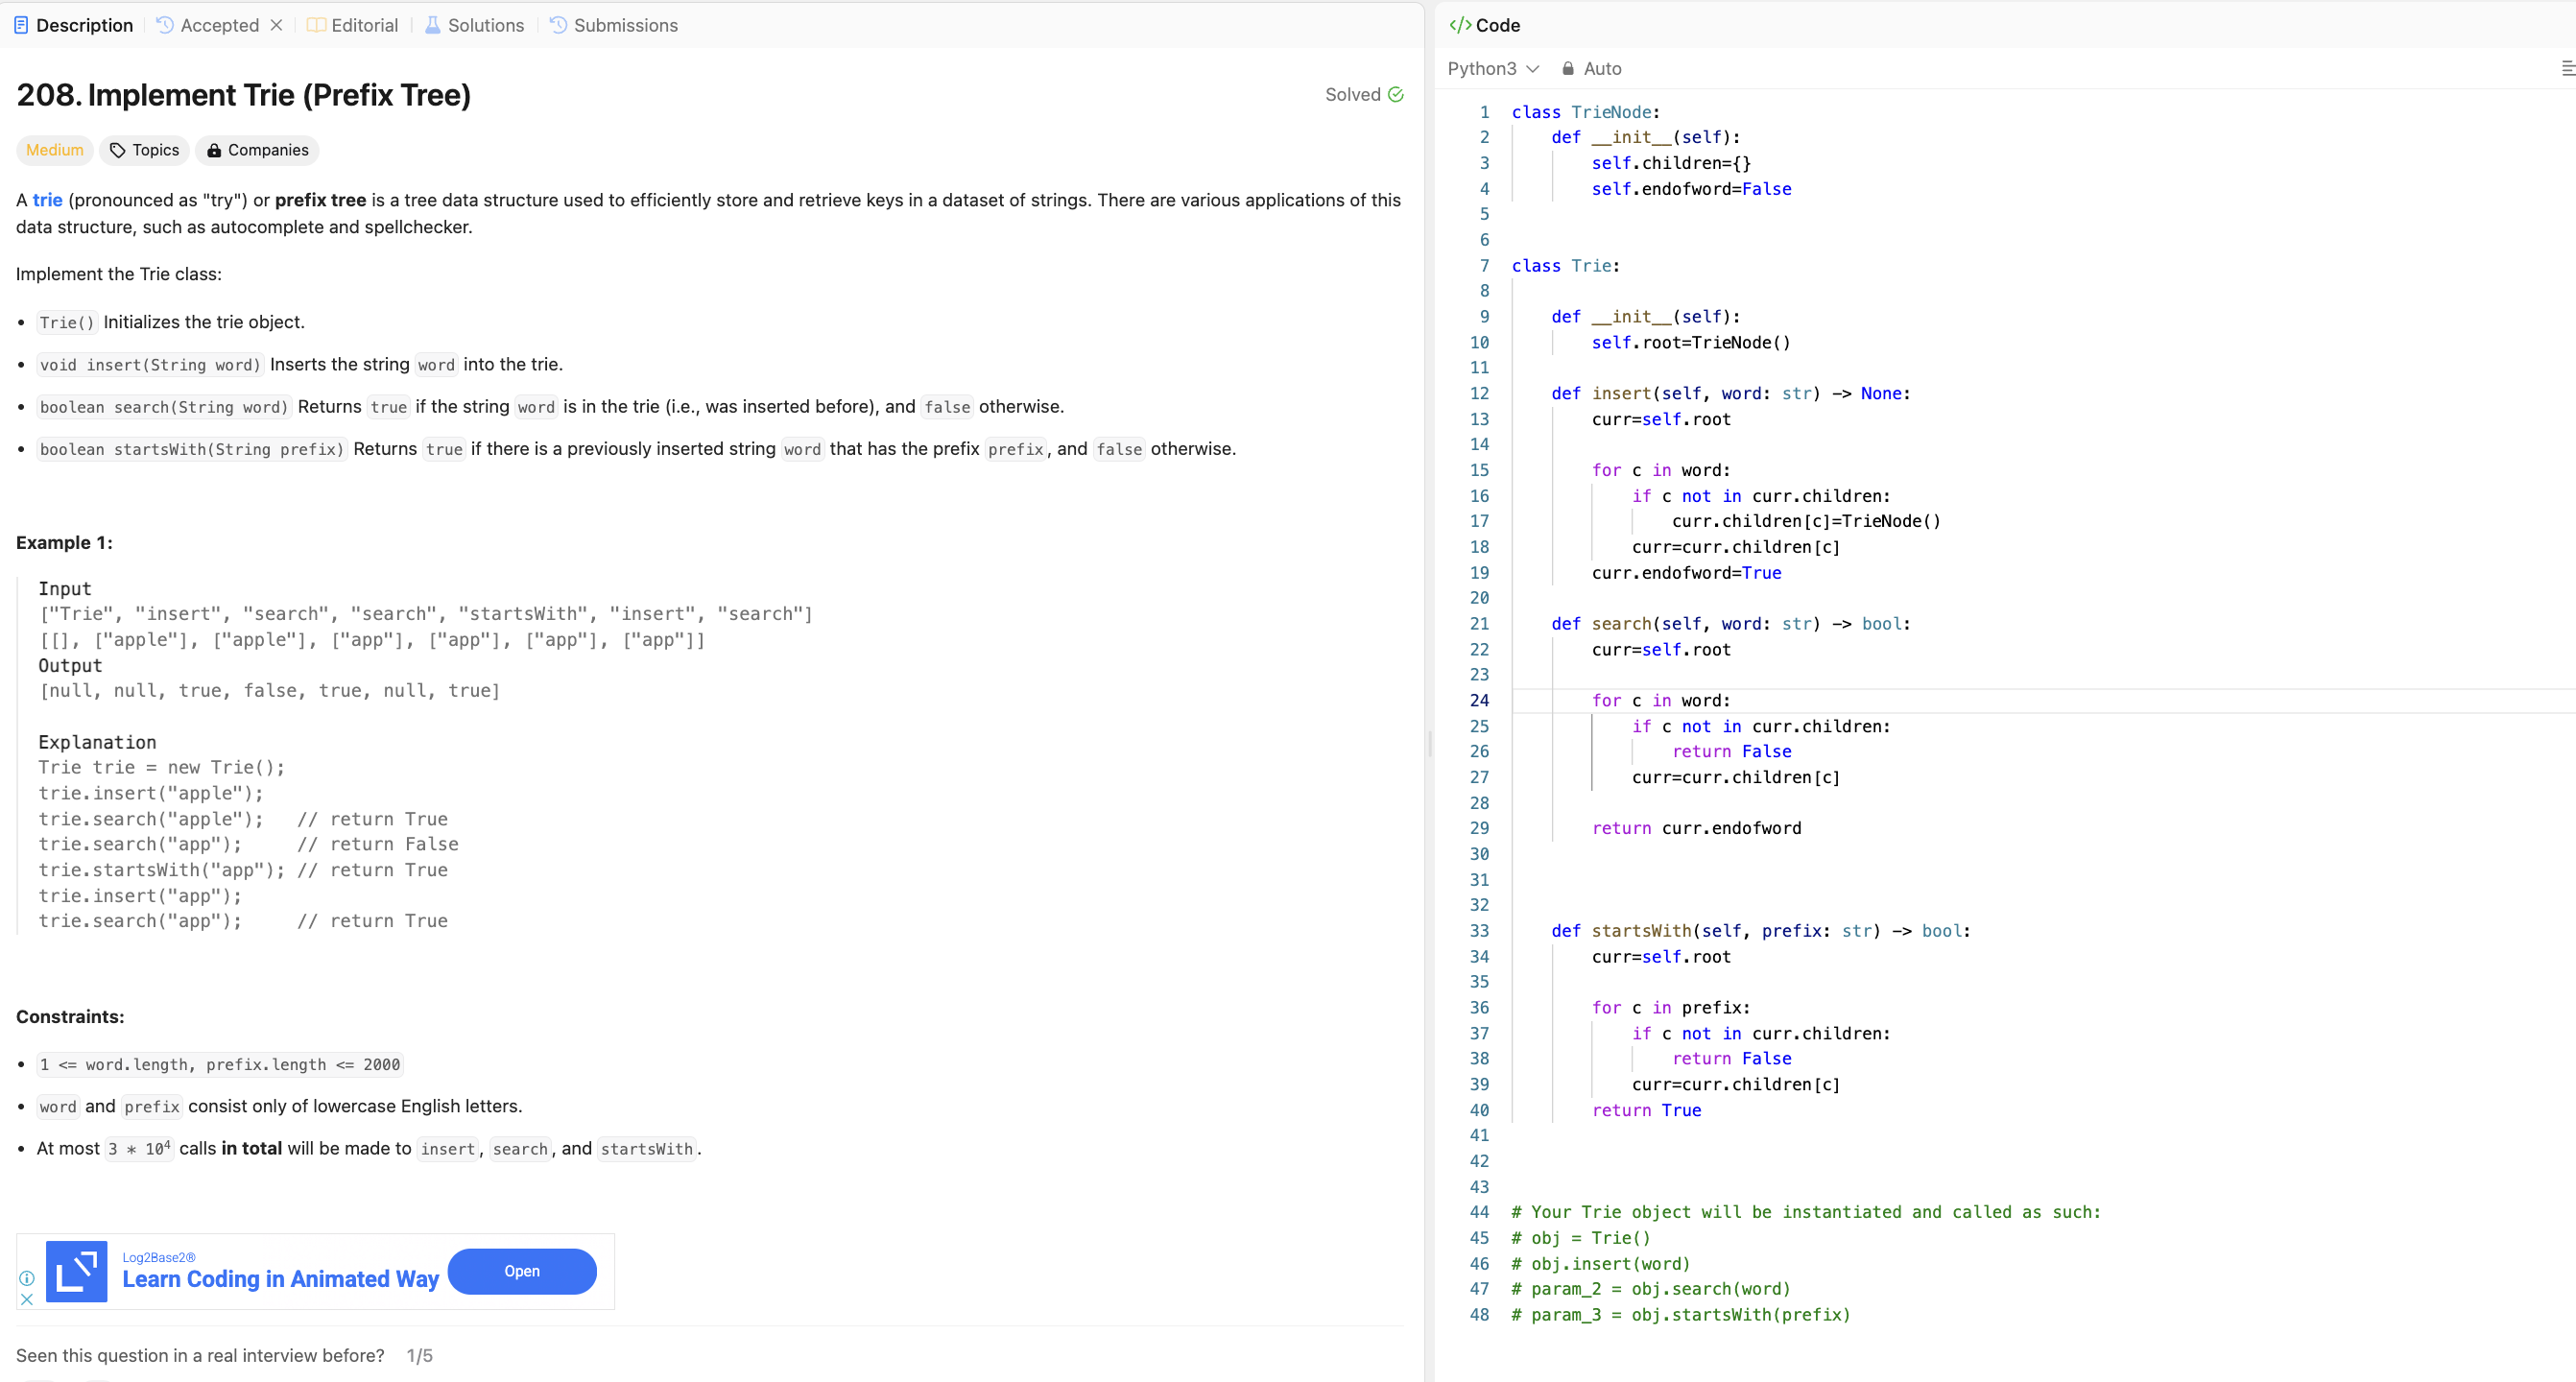

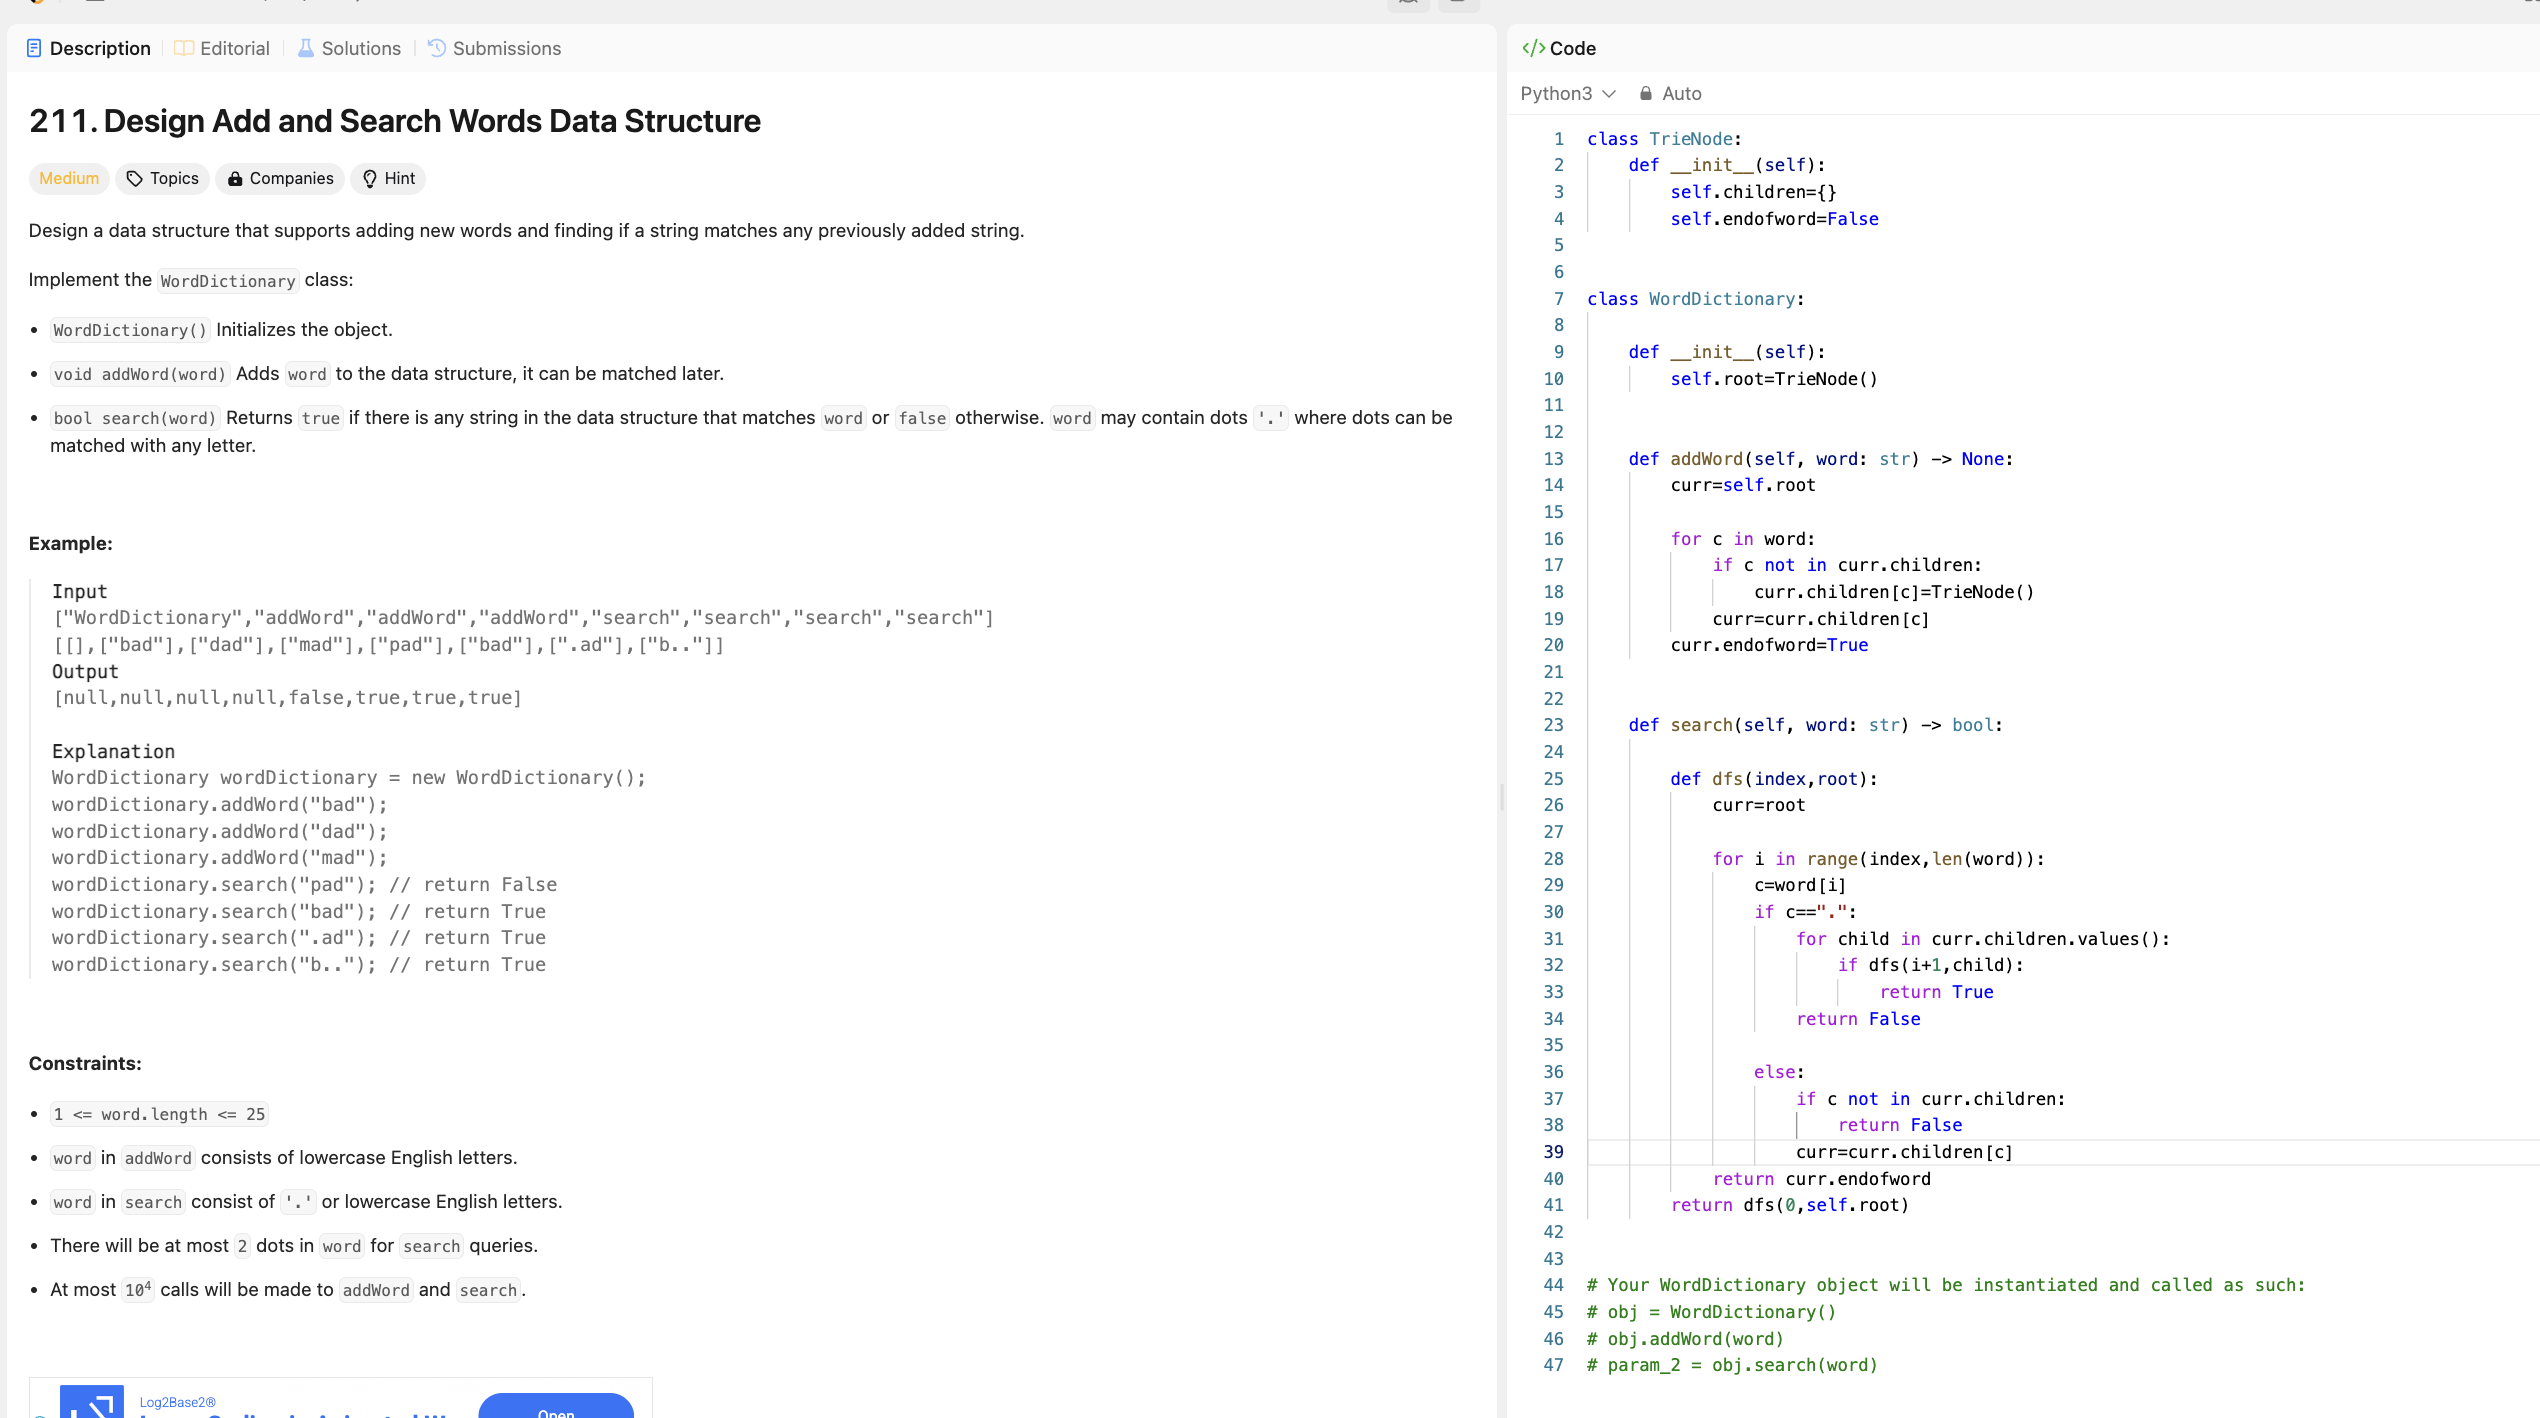

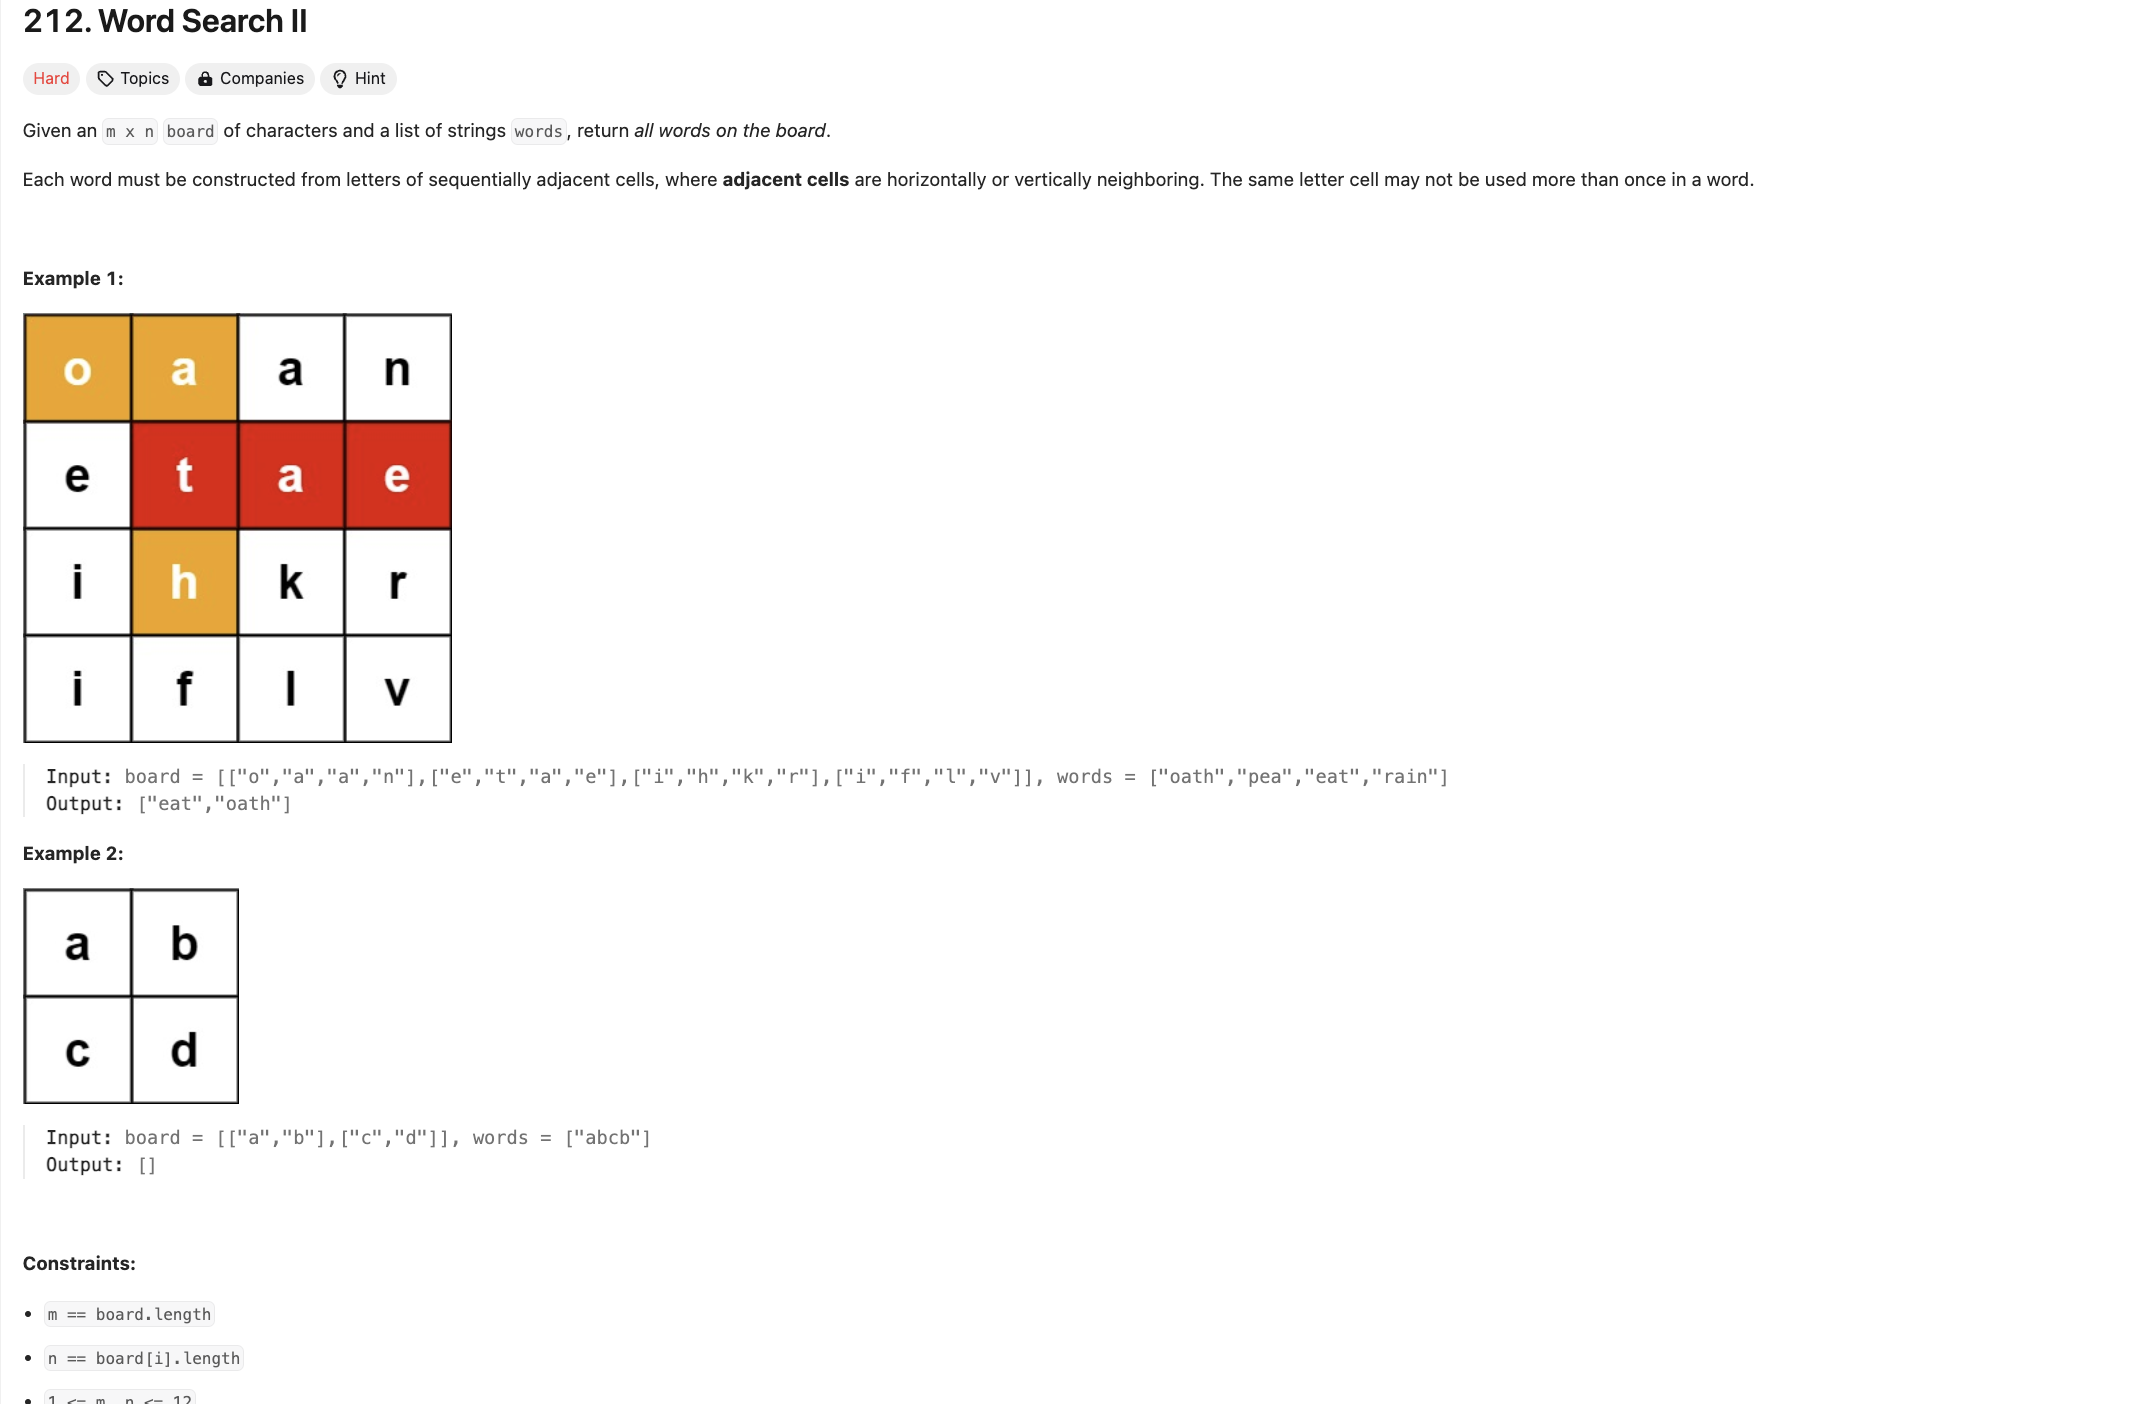

In [4]:
from typing import List

class TrieNode:
    def __init__(self):
        self.children = {}
        self.isWord = False

    def addNode(self, word):
        curr = self
        for c in word:
            if c not in curr.children:
                curr.children[c] = TrieNode()
            curr = curr.children[c]
        curr.isWord = True  # Mark the end of the word


class Solution:
    def findWords(self, board: List[List[str]], words: List[str]) -> List[str]:
        # Build the Trie
        root = TrieNode()
        for w in words:
            root.addNode(w)

        ROW, COL = len(board), len(board[0])
        res, visits = set(), set()

        def dfs(r, c, node, word):
            # Base case: Check boundaries, visited cells, and character in Trie
            if (r < 0 or c < 0 or r >= ROW or c >= COL or
                    (r, c) in visits or board[r][c] not in node.children):
                return
            
            # Add the current cell to the visited set
            visits.add((r, c))
            # Move to the next Trie node
            node = node.children[board[r][c]]
            # Append the character to the current word
            word += board[r][c]

            # If this node represents the end of a word, add it to results
            if node.isWord:
                res.add(word)

            # Explore all four directions
            dfs(r - 1, c, node, word)
            dfs(r + 1, c, node, word)
            dfs(r, c - 1, node, word)
            dfs(r, c + 1, node, word)

            # Backtrack
            visits.remove((r, c))

        # Start DFS from each cell in the board
        for r in range(ROW):
            for c in range(COL):
                dfs(r, c, root, "")

        return list(res)


In [6]:
board = [["o","a","a","n"],["e","t","a","e"],["i","h","k","r"],["i","f","l","v"]]
words = ["oath","pea","eat","rain"]
Solution().findWords(board,words)

['eat', 'oath']